#### Boilerplate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
theoretical_colors = ["black", "maroon", "saddlebrown", "darkgreen", "midnightblue"]
colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

# Validation

### Validation 1: Model fits independent data well

In [3]:
val1_data = pd.read_csv("val1/val1_combined_data.csv")

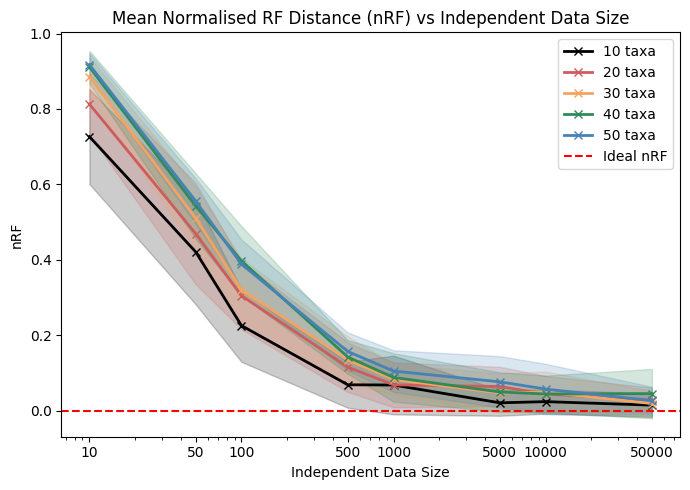

In [4]:
val1_data["tier"] = pd.to_numeric(val1_data["tier"])
val1_data["meanNRF"] = pd.to_numeric(val1_data["meanNRF"])
val1_data["leaves"] = pd.to_numeric(val1_data["leaves"])
val1_data["independent_sites"] = pd.to_numeric(val1_data["independent_sites"])
leaves_vals = sorted(val1_data["leaves"].unique())

fig, axes = plt.subplots(1, 1,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):        
    d = val1_data[(val1_data["leaves"] == leaves_val)].copy()
    if d.empty:
        axes.set_visible(False)
        continue
    grouped = d.groupby("independent_sites")["meanNRF"]
    mean = grouped.mean()
    std = grouped.std()
    x = mean.index.values
    color = colors[i]
    axes.plot(x, mean.values, marker="x", color=color, linewidth=2, label=f"{leaves_val} taxa")
    axes.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )
axes.set_xscale("log")
axes.set_title(f"Mean Normalised RF Distance (nRF) vs Independent Data Size")
axes.set_xlabel("Independent Data Size")
axes.set_ylabel("nRF")
axes.set_xticks(x)
axes.set_xticklabels(x)
axes.axhline(0, color="red", linestyle="--", label="Ideal nRF")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.tight_layout()
plt.legend()
plt.show()

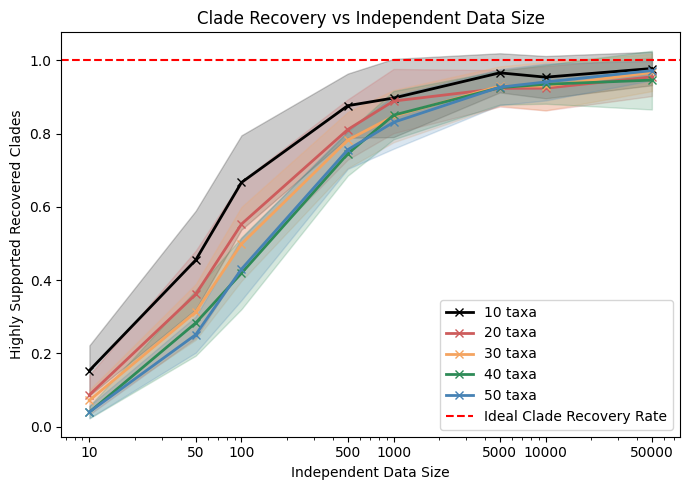

In [5]:
fig, axes = plt.subplots(1, 1,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):        
    d = val1_data[(val1_data["leaves"] == leaves_val)].copy()
    if d.empty:
        axes.set_visible(False)
        continue
    grouped = d.groupby("independent_sites")["HighSupportCladesProp"]
    mean = grouped.mean()
    std = grouped.std()
    x = mean.index.values
    color = colors[i]
    axes.plot(x, mean.values, marker="x", color=color, linewidth=2, label=f"{leaves_val} taxa")
    axes.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )
axes.set_xscale("log")
axes.set_title(f"Clade Recovery vs Independent Data Size")
axes.set_xlabel("Independent Data Size")
axes.set_ylabel("Highly Supported Recovered Clades")
axes.set_xticks(x)
axes.set_xticklabels(x)
axes.axhline(1, color="red", linestyle="--", label="Ideal Clade Recovery Rate")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.tight_layout()
plt.legend()
plt.show()

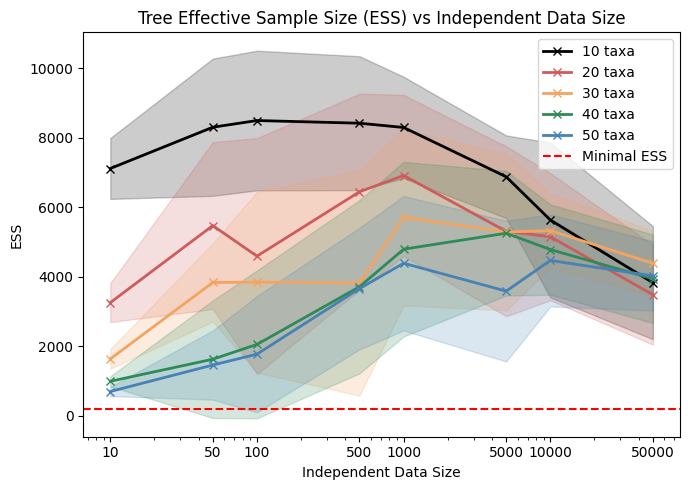

In [6]:
fig, axes = plt.subplots(1, 1,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):        
    d = val1_data[(val1_data["leaves"] == leaves_val)].copy()
    if d.empty:
        axes.set_visible(False)
        continue
    grouped = d.groupby("independent_sites")["jointESS"]
    mean = grouped.mean()
    std = grouped.std()
    x = mean.index.values
    color = colors[i]
    axes.plot(x, mean.values, marker="x", color=color, linewidth=2, label=f"{leaves_val} taxa")
    axes.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )
axes.set_xscale("log")
axes.set_title(f"Tree Effective Sample Size (ESS) vs Independent Data Size")
axes.set_xlabel("Independent Data Size")
axes.set_ylabel("ESS")
axes.set_xticks(x)
axes.set_xticklabels(x)
axes.axhline(200, color="red", linestyle="--", label="Minimal ESS")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.tight_layout()
plt.legend()
plt.show()

### Validation 2: Dependent Data generates as expected

In [7]:
sizes = pd.read_csv("val2/exp2_combined_sizes.csv")

/rds/general/user/jst21/home/.venv/lib64/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/.venv/lib64/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/.venv/lib64/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/.venv/lib64/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/.venv/lib64/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/

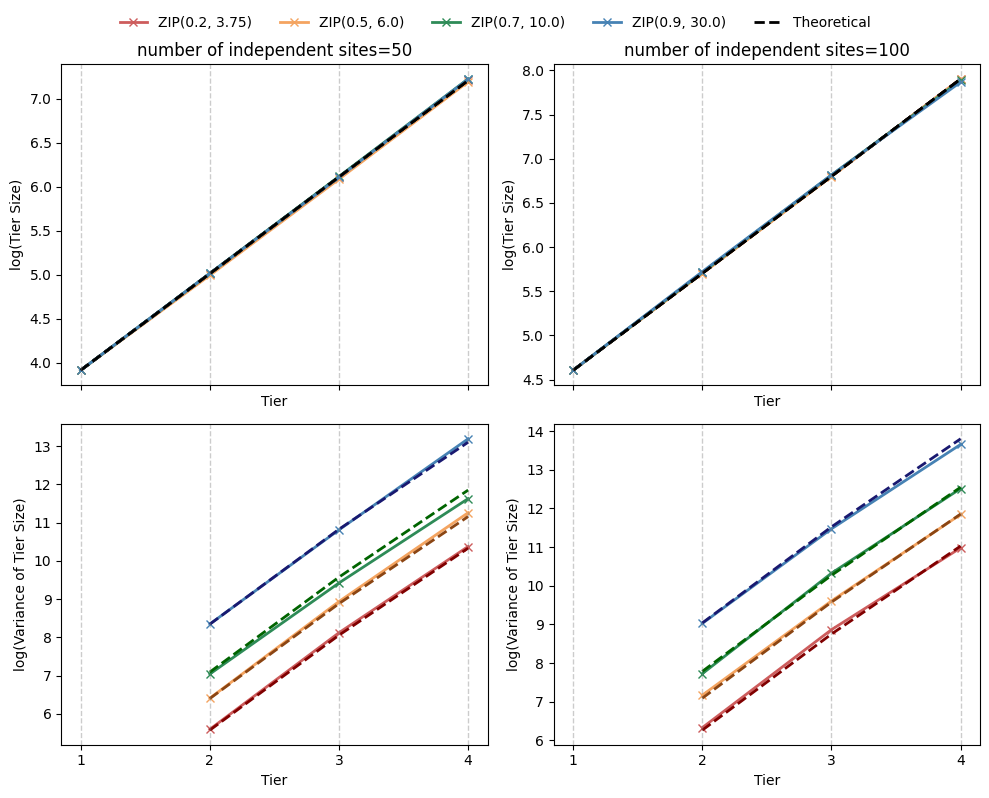

In [ ]:
sites_vals = sorted(sizes["independent_sites"].unique())

sites_vals = sites_vals[1:3]

fig, axes = plt.subplots(
    2,
    len(sites_vals),
    figsize=(5 * len(sites_vals), 8),
    sharex=True
)

for j, sites_val in enumerate(sites_vals):
    d = sizes[
        (sizes["independent_sites"] == sites_val)
    ].copy()

    if d.empty:
        axes[0, j].set_visible(False)
        continue

    methods = d["site_dep_param"].unique()
    for k, m in enumerate(methods):
        p, lam = list(float(x) for x in m[4:-1].split(', '))
        dm = d[d["site_dep_param"] == m]
        grouped = dm.groupby("current tier")["size"]
        mean = np.log(grouped.mean())
        var = np.log(grouped.var())
        x = mean.index.values
        color = colors[k+1]
        axes[0, j].plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
        axes[1, j].plot(x, var.values, marker='x', color=color, linewidth=2, label=m)

        # Theoretical Values
        x = np.array([1, 2, 3, 4])
        ### If lambda(1-p) = mu, mu = 3 != 1
        mean = np.log((1-p)*lam)
        var = np.log((1-p)*lam + p*(1-p)*lam**2)
        variances = np.log(sites_val) + var + (x[1:]-2)*mean + np.log(np.exp(mean)**(x[1:]-1) - 1) - np.log(np.exp(mean)- 1)
        axes[1, j].plot(x[1:], variances, color=theoretical_colors[k+1], linestyle="--", linewidth=2)
        axes[0, j].plot(x, np.log(sites_val) + (x-1)*mean, color=theoretical_colors[0], linestyle="--", linewidth=2, label='Theoretical')
        axes[0, j].set_title(f"number of independent sites={sites_val}")
        axes[0, j].set_xlabel("Tier")
        axes[0, j].set_ylabel("log(Tier Size)")
        axes[1, j].set_xlabel("Tier")
        axes[1, j].set_ylabel("log(Variance of Tier Size)")
        axes[1, j].set_xticks([1, 2, 3, 4])
    for x in [1, 2, 3, 4]:
        axes[0, j].axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
        axes[1, j].axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")

handles, labels = axes[0, 0].get_legend_handles_labels()

for i in range(4):
    idx = labels.index("Theoretical")
    handles.append(handles.pop(idx))
    labels.append(labels.pop(idx))

by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Experiments

### Experiment 1: Proportion of Dependent Data

In [28]:
df = pd.read_csv("exp1/exp1_combined_data.csv")

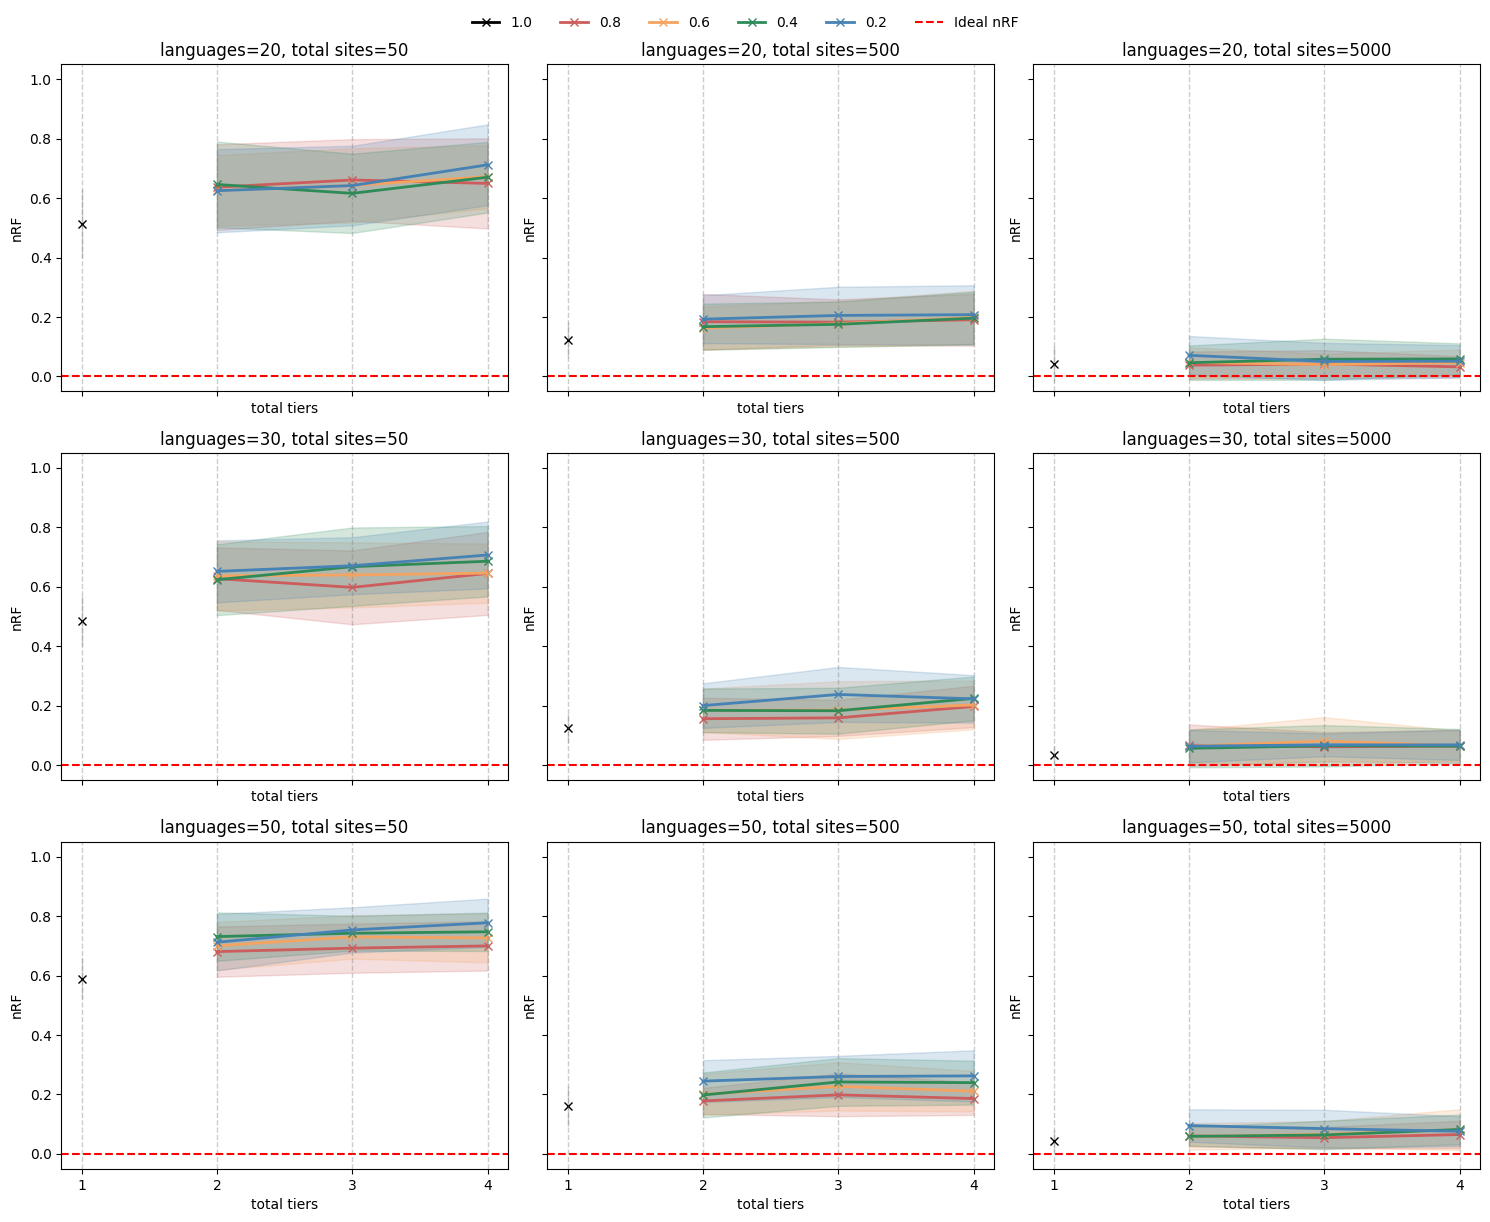

In [29]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["total_sites"] = pd.to_numeric(df["total_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["meanNRF"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("nRF")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(0, color="red", linestyle="--", label="Ideal nRF")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].set_ylim(-0.05, 1.05)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

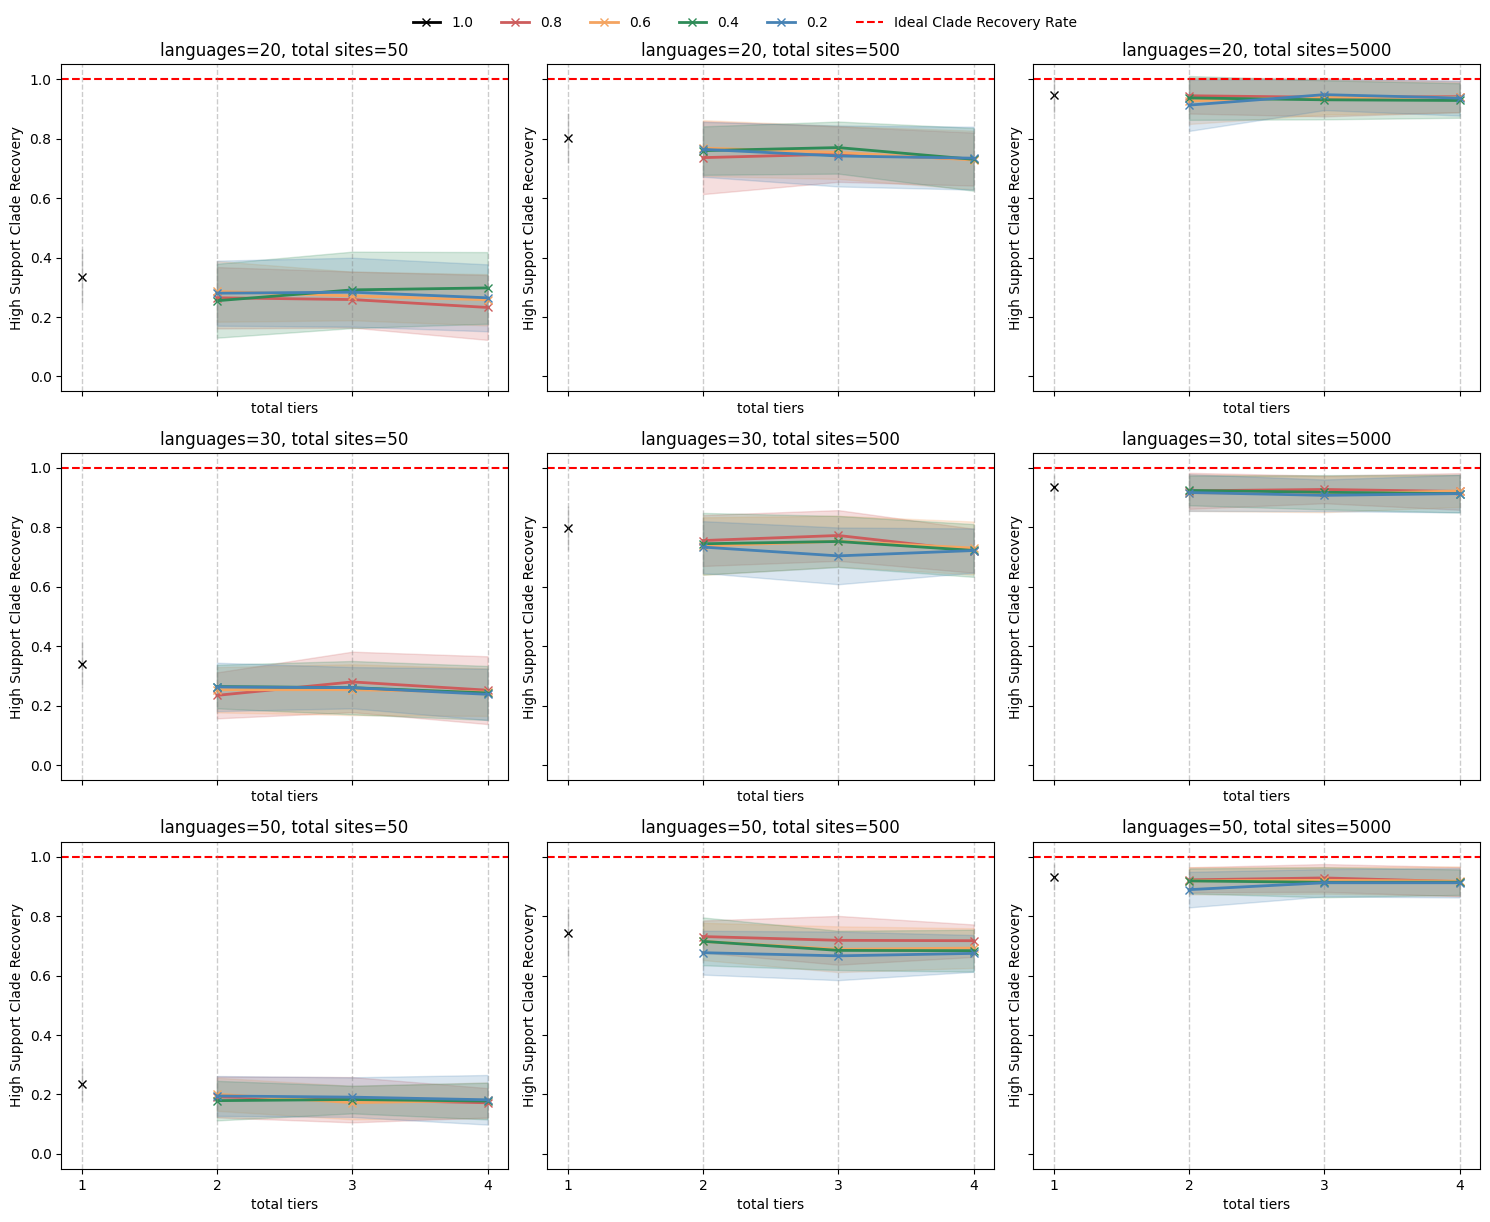

In [30]:
leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]


fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["HighSupportCladesProp"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("High Support Clade Recovery")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(1, color="red", linestyle="--", label="Ideal Clade Recovery Rate")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].set_ylim(-0.05, 1.05)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

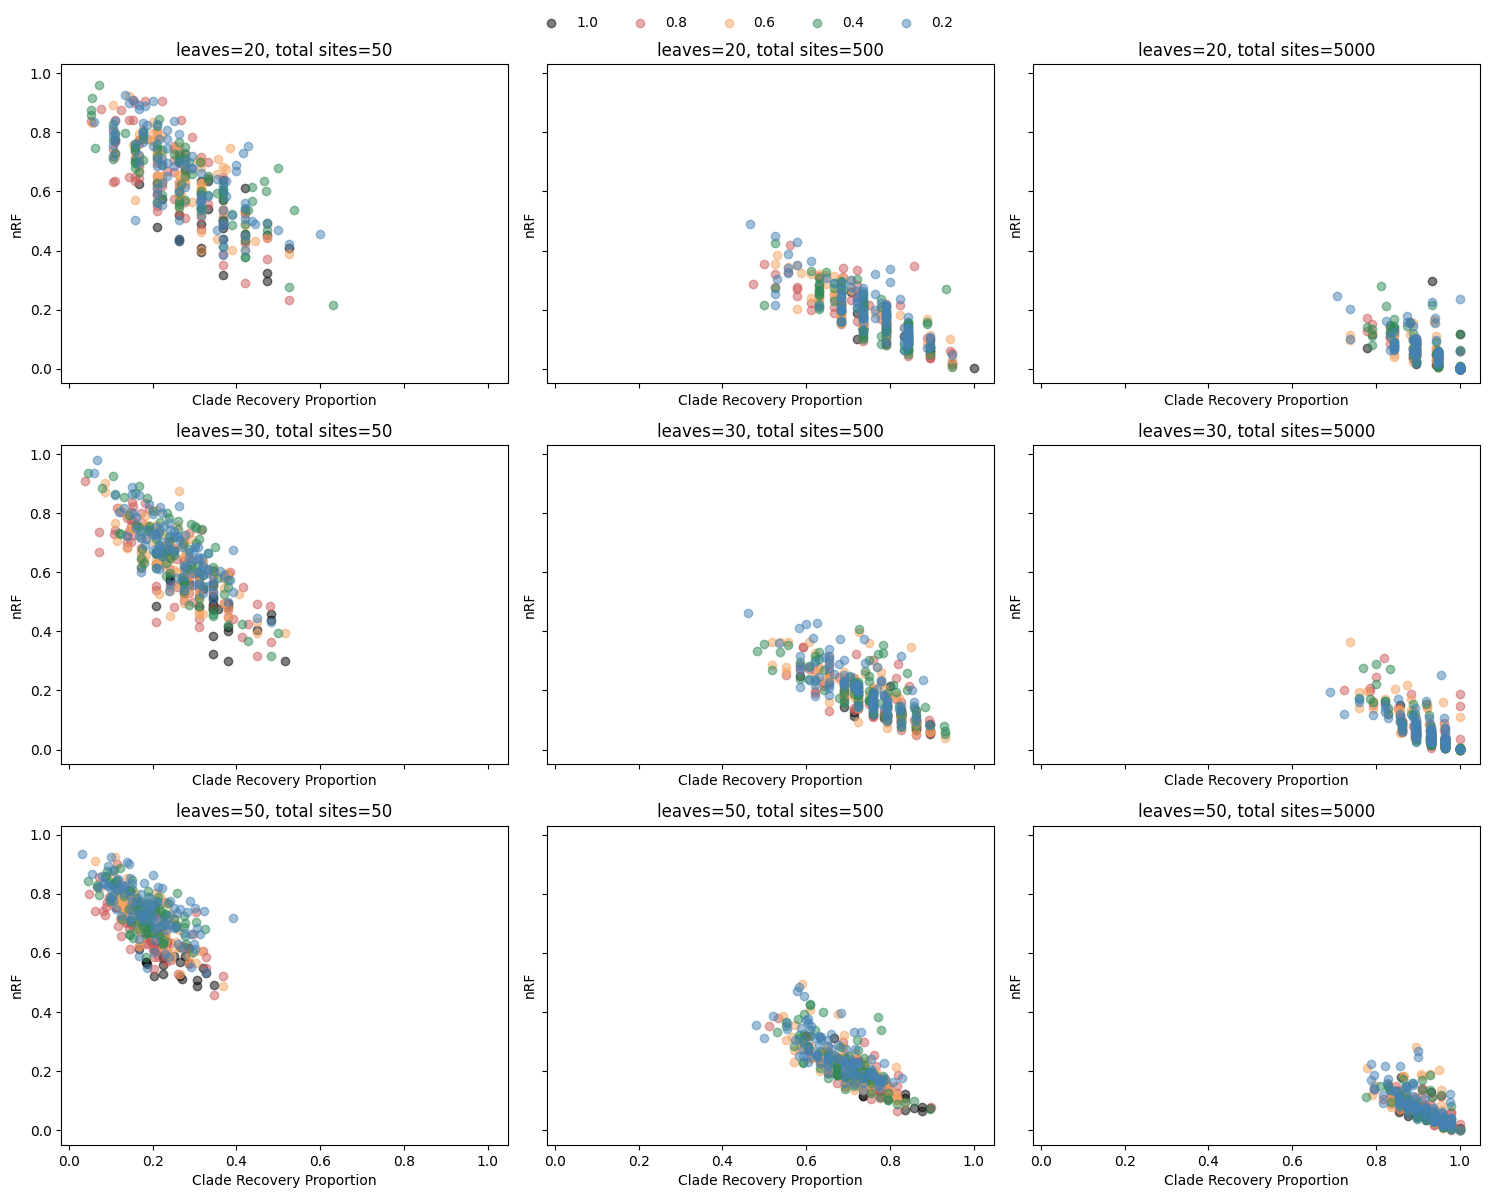

In [12]:
# NOT USED
fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[
            (df["leaves"] == leaves_val) &
            (df["total_sites"] == sites_val)
        ].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["prob"].unique()
        for k, m in enumerate(methods):
            dm = d[d["prob"] == m]
            ax.scatter(
                dm["HighSupportCladesProp"],
                dm["meanNRF"],
                alpha=0.5,
                label=m,
                color=colors[k]
            )
        ax.set_title(f"leaves={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("Clade Recovery Proportion")
        ax.set_ylabel("nRF")


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

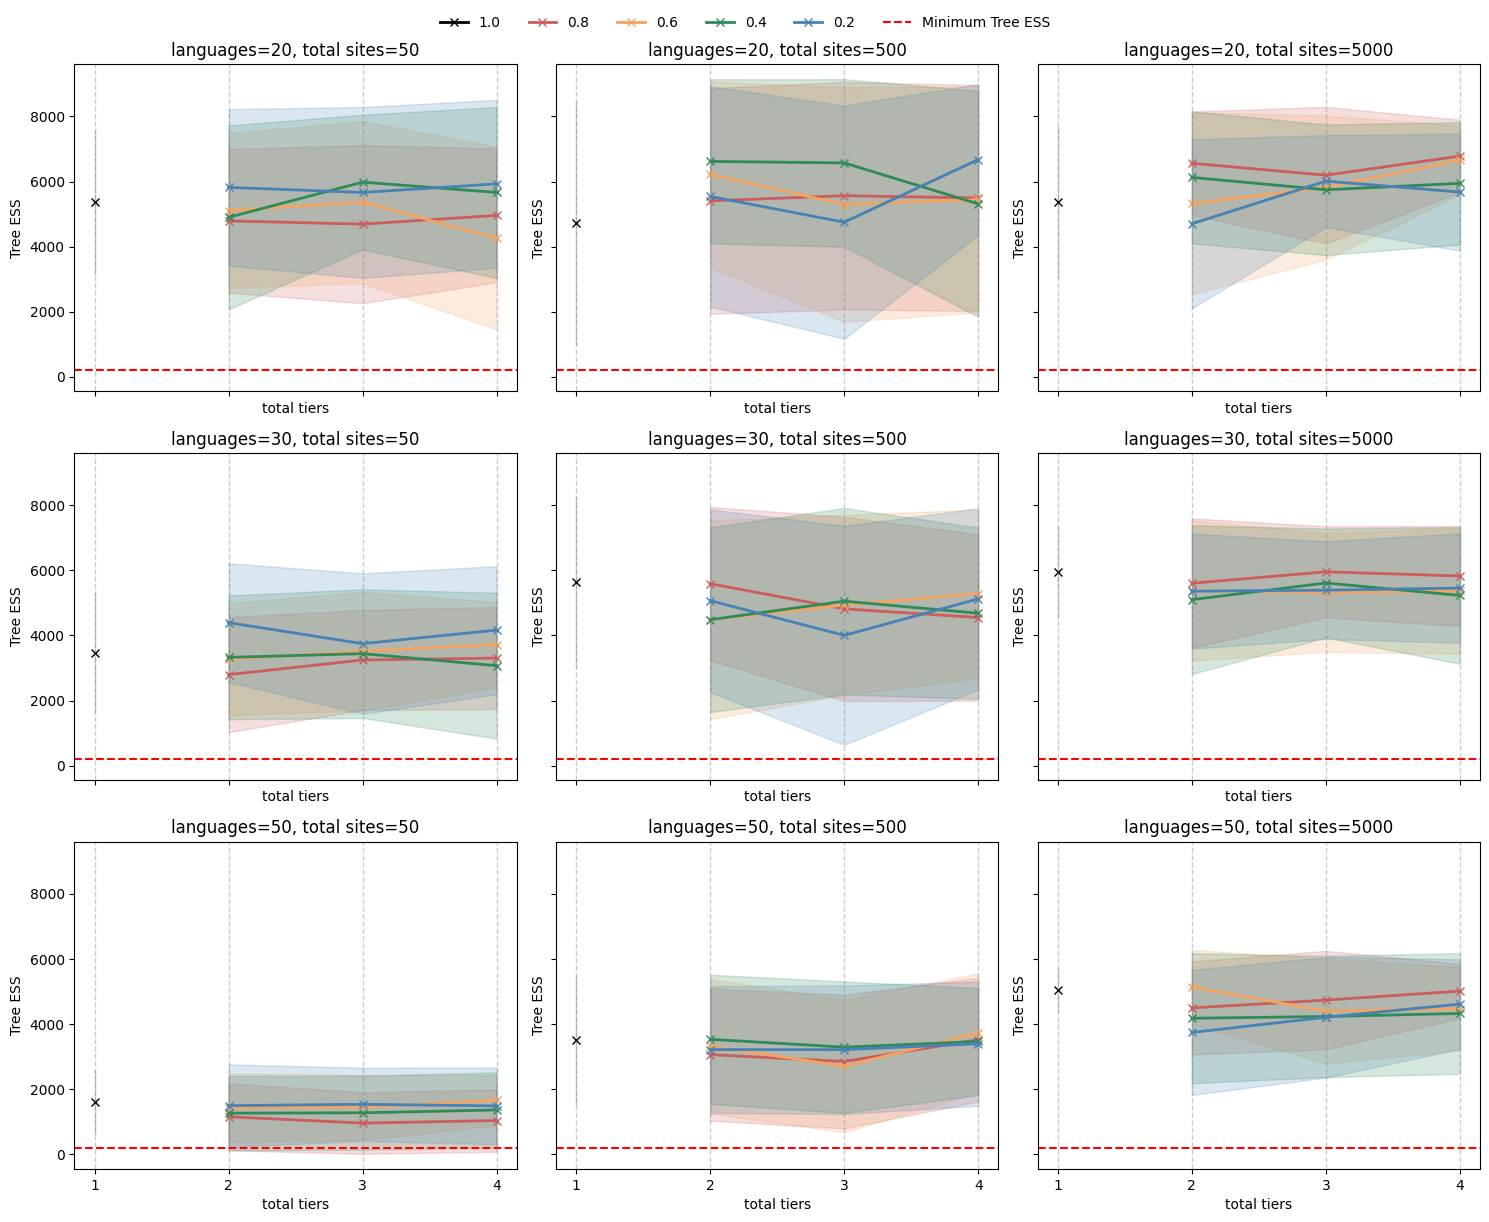

In [32]:
leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["jointESS"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("Tree ESS")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(200, color="red", linestyle="--", label="Minimum Tree ESS")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

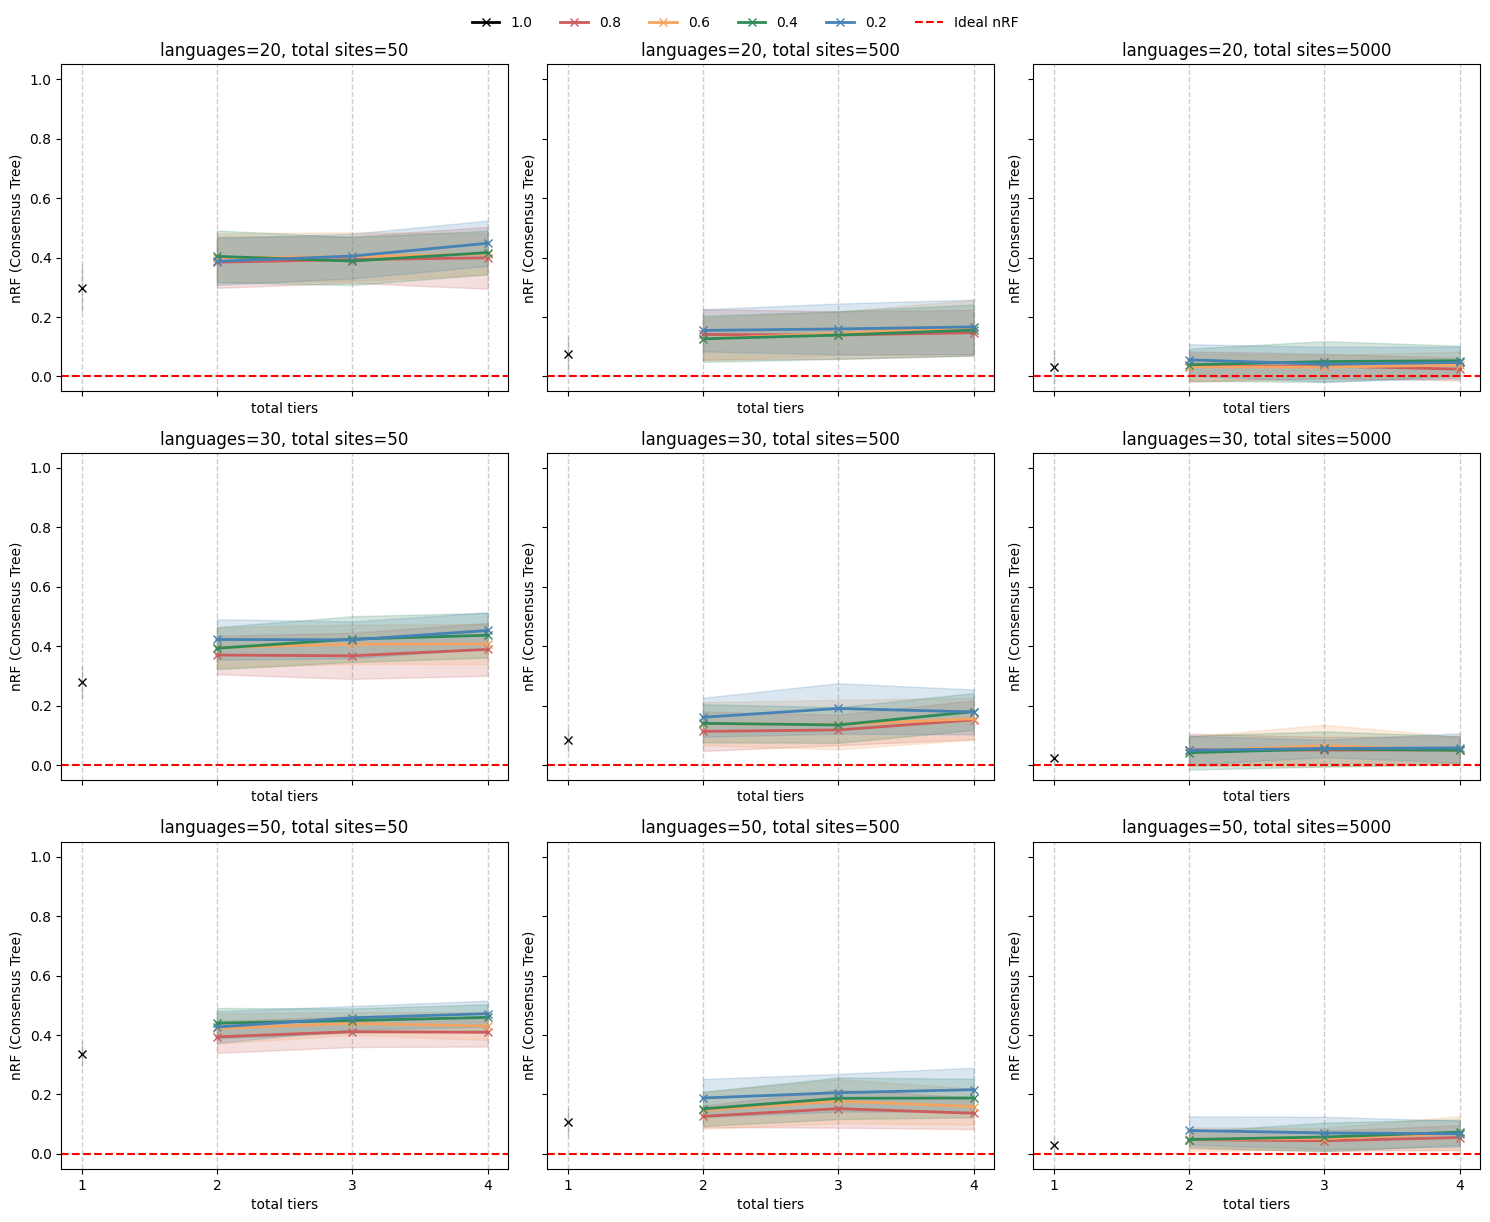

In [33]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["total_sites"] = pd.to_numeric(df["total_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]


fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["NRFConsensus"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("nRF (Consensus Tree)")
        ax.axhline(0, color="red", linestyle="--", label="Ideal nRF")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].set_ylim(-0.05, 1.05)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

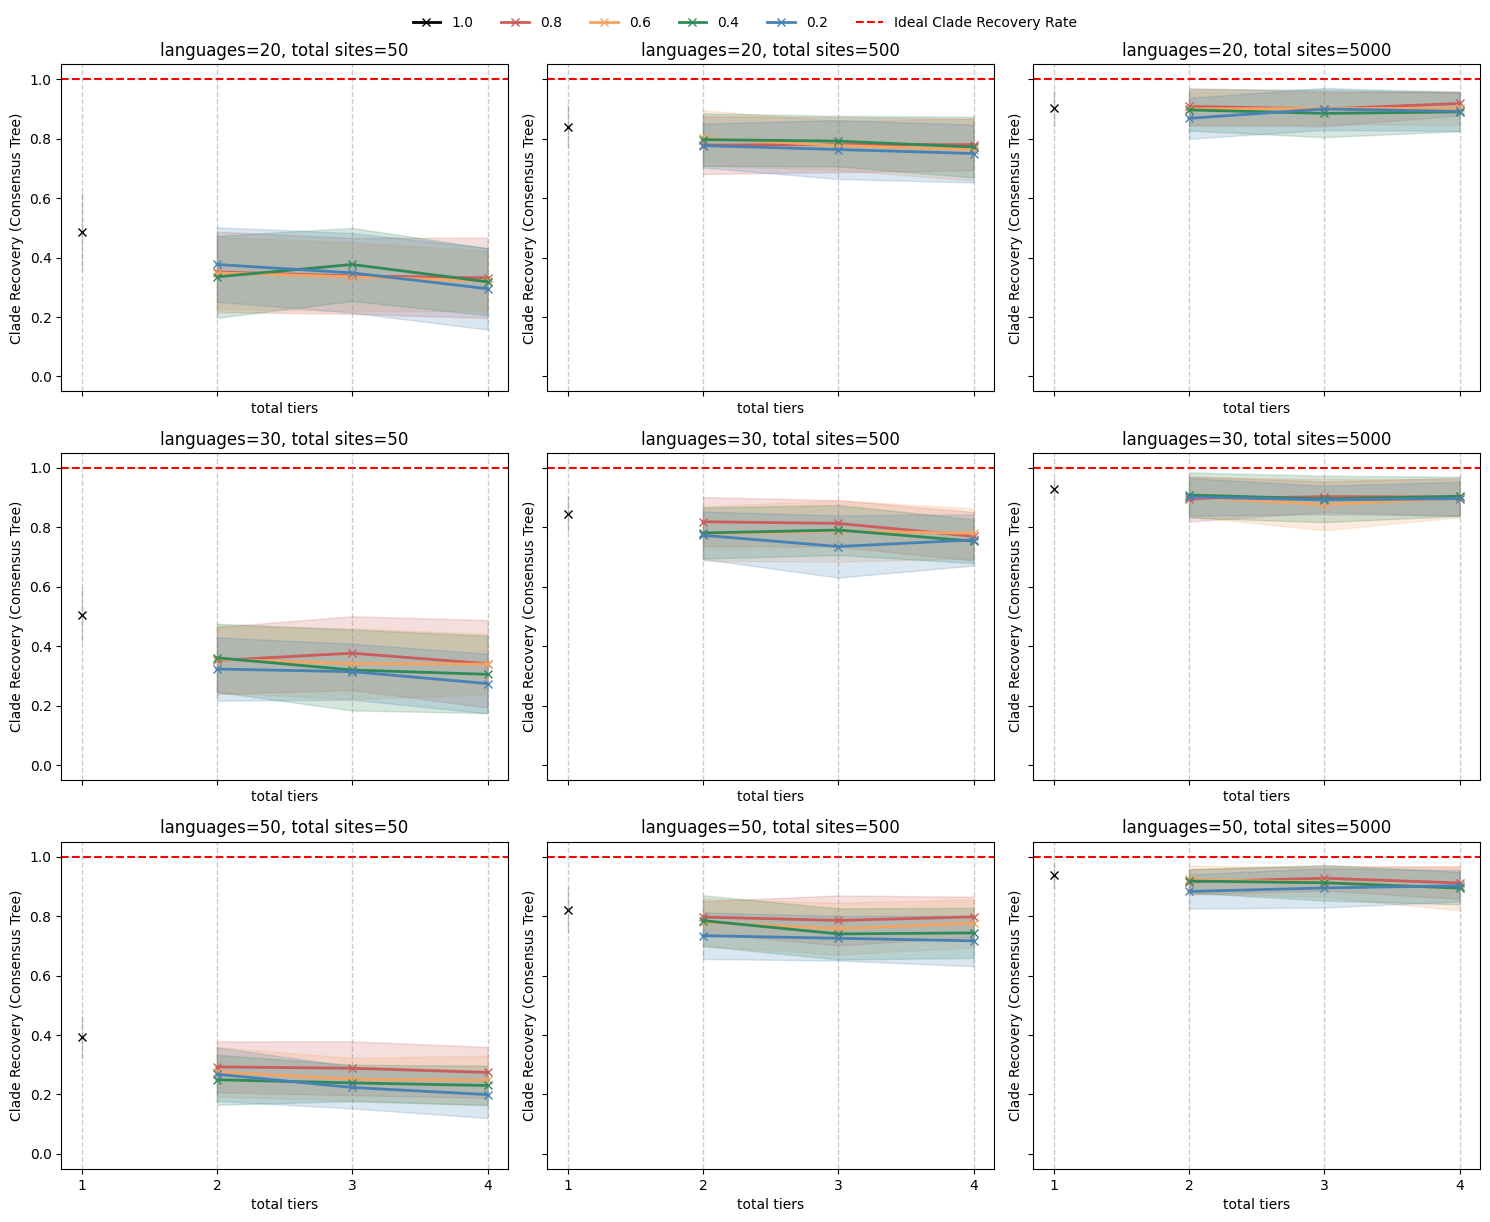

In [35]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["total_sites"] = pd.to_numeric(df["total_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]


fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["CladeRecoveryConsensus"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("Clade Recovery (Consensus Tree)")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(1, color="red", linestyle="--", label="Ideal Clade Recovery Rate")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].set_ylim(-0.05, 1.05)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

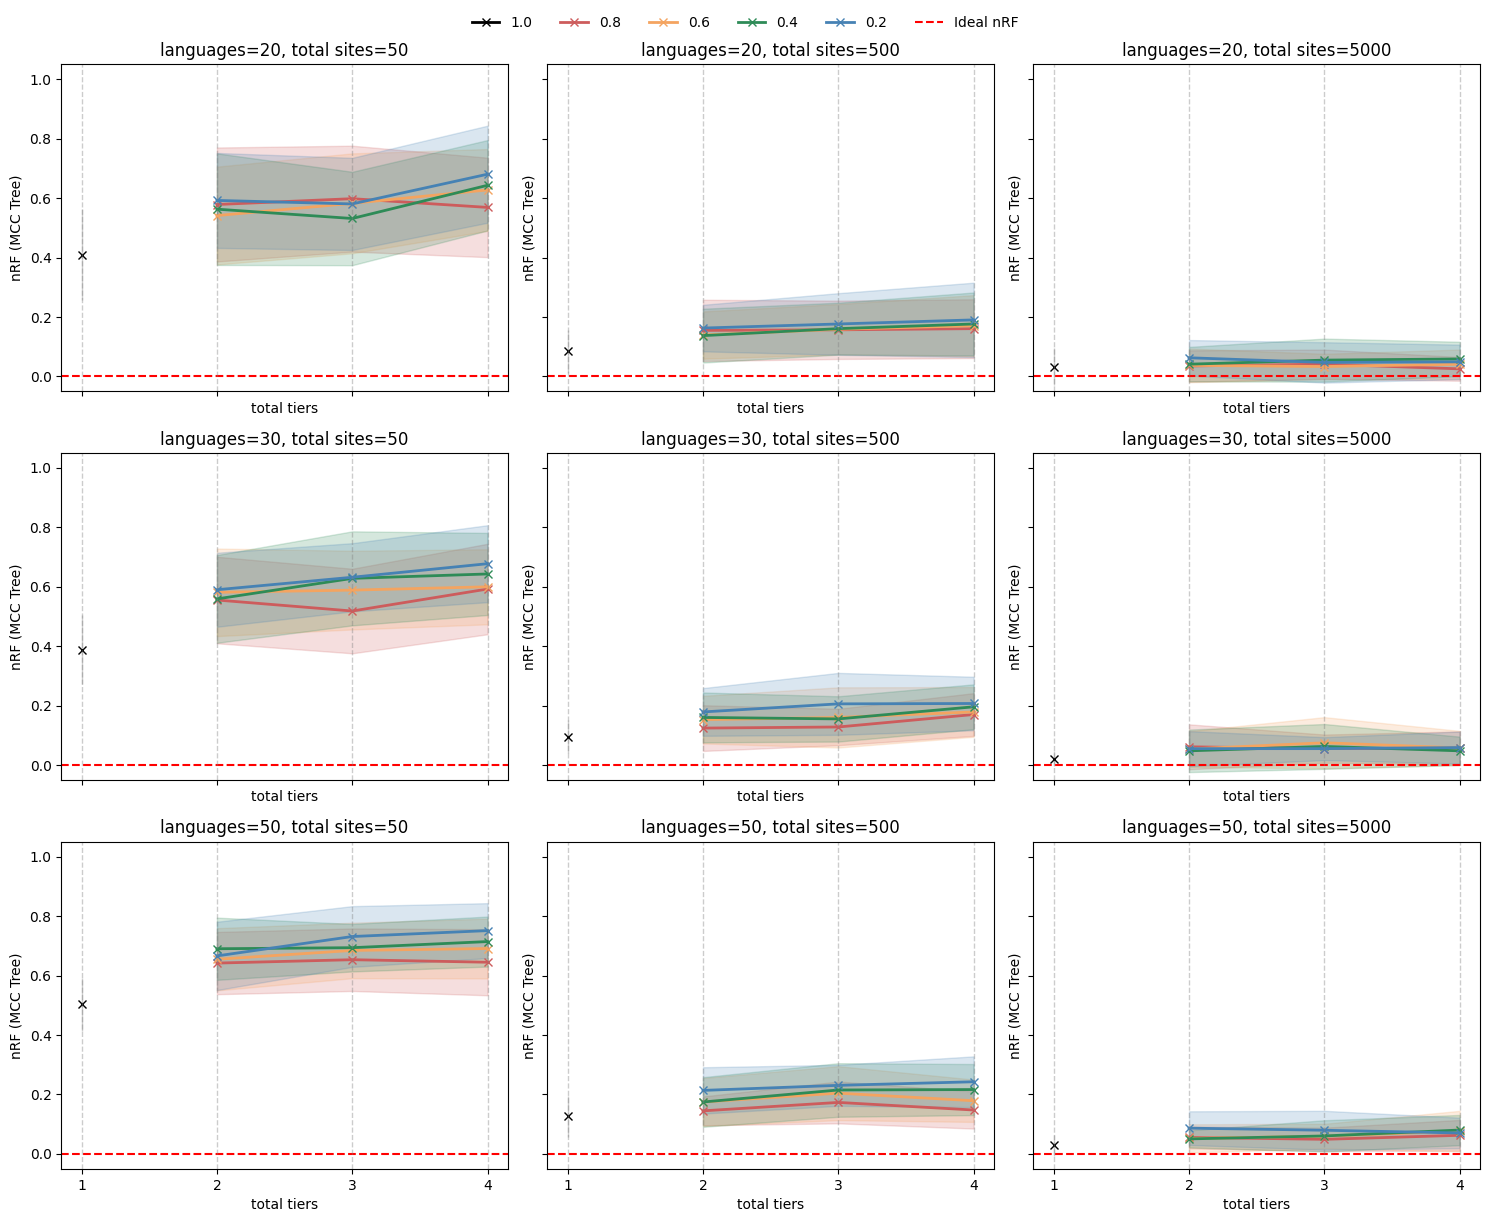

In [36]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["total_sites"] = pd.to_numeric(df["total_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]


fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["NRFMCC"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("nRF (MCC Tree)")
        ax.axhline(0, color="red", linestyle="--", label="Ideal nRF")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].set_ylim(-0.05, 1.05)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

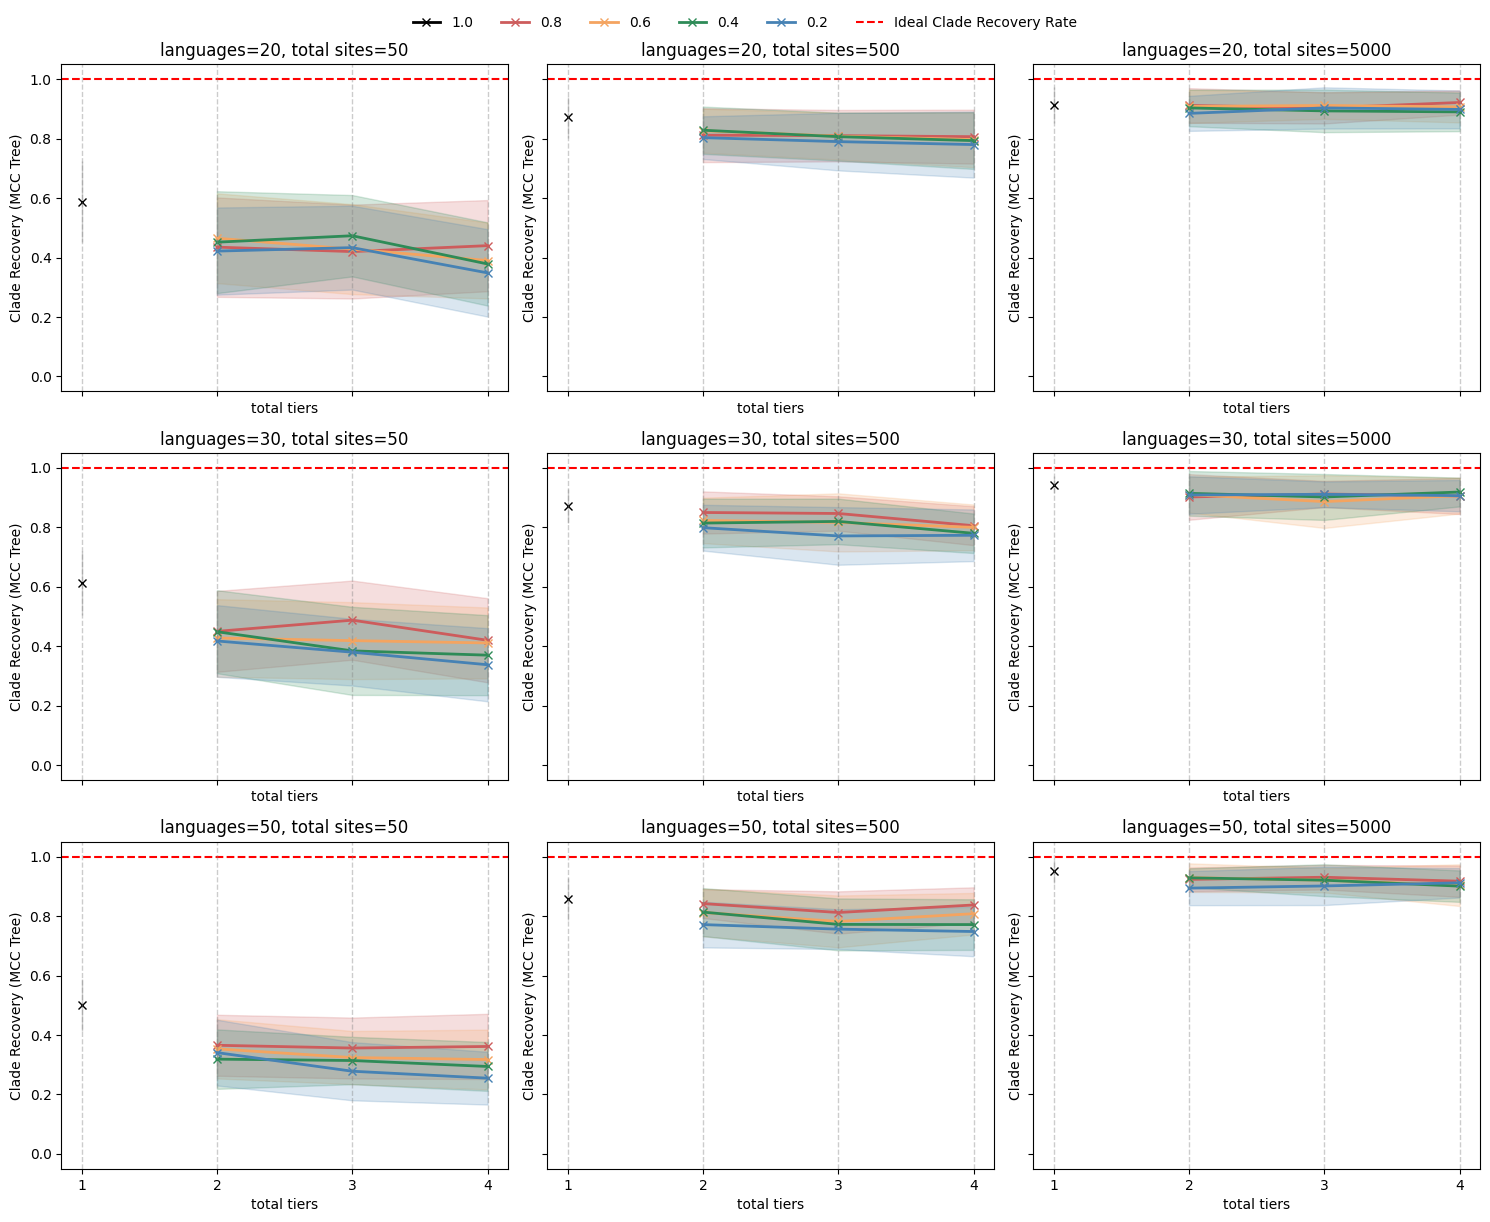

In [37]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["total_sites"] = pd.to_numeric(df["total_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["total_sites"].unique())

# Comment out for full analysis
leaves_idx = [1, 2, 4]
leaves_vals = [leaves_vals[i] for i in leaves_idx]
sites_idx = [0, 2, 4]
sites_vals = [sites_vals[i] for i in sites_idx]


fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["total_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        prob = d["prob"].unique()
        for k, m in enumerate(prob):
            dm = d[d["prob"] == m]
            grouped = dm.groupby("tier")["CladeRecoveryMCC"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, total sites={sites_val}")
        ax.set_xlabel("total tiers")
        ax.set_ylabel("Clade Recovery (MCC Tree)")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(1, color="red", linestyle="--", label="Ideal Clade Recovery Rate")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].set_ylim(-0.05, 1.05)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

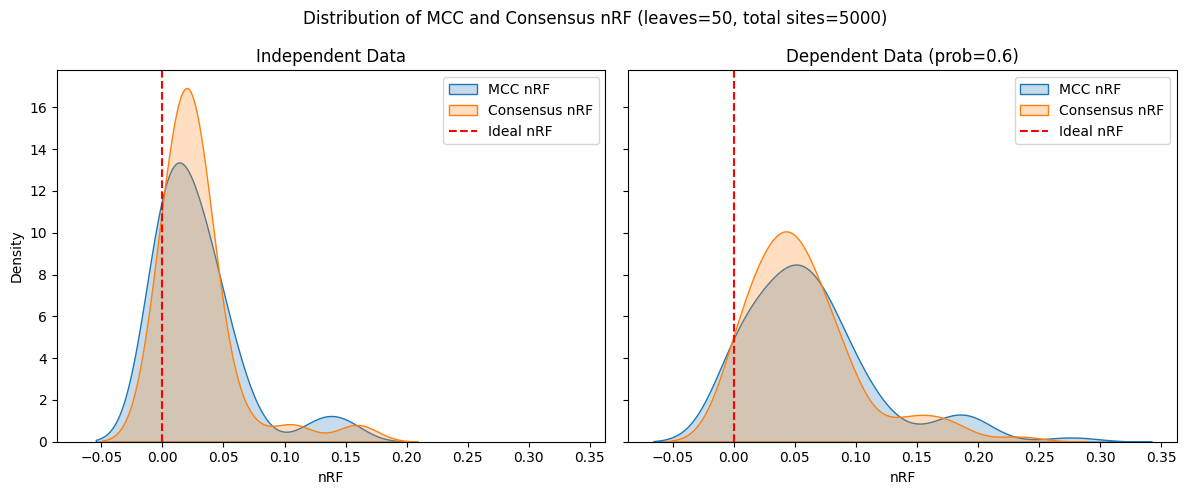

In [54]:
l, s = leaves_vals[2], sites_vals[2]
d = df[(df["leaves"] == l) & (df["total_sites"] == s)].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Independent
d_ind = d[d["prob"] == 1]

sns.kdeplot(
    d_ind["NRFMCC"],
    label="MCC nRF",
    fill=True,
    ax=axes[0]
)
sns.kdeplot(
    d_ind["NRFConsensus"],
    label="Consensus nRF",
    fill=True,
    ax=axes[0]
)

axes[0].set_title("Independent Data")
axes[0].set_xlabel("nRF")
axes[0].set_ylabel("Density")
axes[0].axvline(0, color="red", linestyle="--", label="Ideal nRF")
axes[0].legend()

# Example dependent dataset
dependent_prob = sorted([p for p in d["prob"].unique() if p != 1])[2]
d_dep = d[d["prob"] == dependent_prob]

sns.kdeplot(
    d_dep["NRFMCC"],
    label="MCC nRF",
    fill=True,
    ax=axes[1]
)
sns.kdeplot(
    d_dep["NRFConsensus"],
    label="Consensus nRF",
    fill=True,
    ax=axes[1]
)

axes[1].set_title(f"Dependent Data (prob={dependent_prob})")
axes[1].set_xlabel("nRF")
axes[1].axvline(0, color="red", linestyle="--", label="Ideal nRF")
axes[1].legend()

fig.suptitle(
    f"Distribution of MCC and Consensus nRF (leaves={l}, total sites={s})"
)

plt.tight_layout()
plt.show()

### Experiment 2: Adding Dependent Data

In [18]:
df = pd.read_csv("exp2/exp2_combined_data.csv")

In [19]:
df[df['leaves'].isnull()]

,meanRF,meanNRF,HighSupportCladesProp,RFConsensus,NRFConsensus,CladeRecoveryConsensus,RFMCC,NRFMCC,CladeRecoveryMCC,likelihoodESS,priorESS,jointESS,tier,ZIP,leaves,independent_sites
4680,70.262193,4.719692,0.949489,0.000862,0.038462,1731.568900,554.667798,583.540082,1.0,independent,40.0,10.0,NaN,NaN,NaN,NaN
4681,72.189757,3.476877,0.975537,0.000635,0.043478,1439.327576,561.052719,552.485266,2.0,"ZIP(0.2, 3.75)",40.0,10.0,NaN,NaN,NaN,NaN
4682,68.945673,4.276270,0.931698,0.000781,0.083333,3023.356016,1601.986177,1615.884887,3.0,"ZIP(0.2, 3.75)",40.0,10.0,NaN,NaN,NaN,NaN
4683,63.781580,6.399843,0.861913,0.001169,0.185185,2733.592053,1357.062594,1347.214966,4.0,"ZIP(0.2, 3.75)",40.0,10.0,NaN,NaN,NaN,NaN
4684,60.945673,10.156270,0.823590,0.001855,0.121212,3522.128888,1602.528447,1590.243775,2.0,"ZIP(0.5, 6.0)",40.0,10.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7652,83.947561,7.209694,0.893059,0.000816,0.088235,1789.842339,1088.881402,967.192089,3.0,"ZIP(0.7, 10.0)",50.0,10.0,NaN,NaN,NaN,NaN
7653,85.705366,9.455403,0.911759,0.001070,0.058824,1733.737564,839.169323,825.508702,4.0,"ZIP(0.7, 10.0)",50.0,10.0,NaN,NaN,NaN,NaN
7654,68.967670,23.588399,0.733699,0.002670,0.121951,324.265183,26.957542,35.070010,2.0,"ZIP(0.9, 30.0)",50.0,10.0,NaN,NaN,NaN,NaN
7655,87.787357,7.739222,0.933908,0.000876,0.062500,1695.129434,1094.293637,1013.159156,3.0,"ZIP(0.9, 30.0)",50.0,10.0,NaN,NaN,NaN,NaN


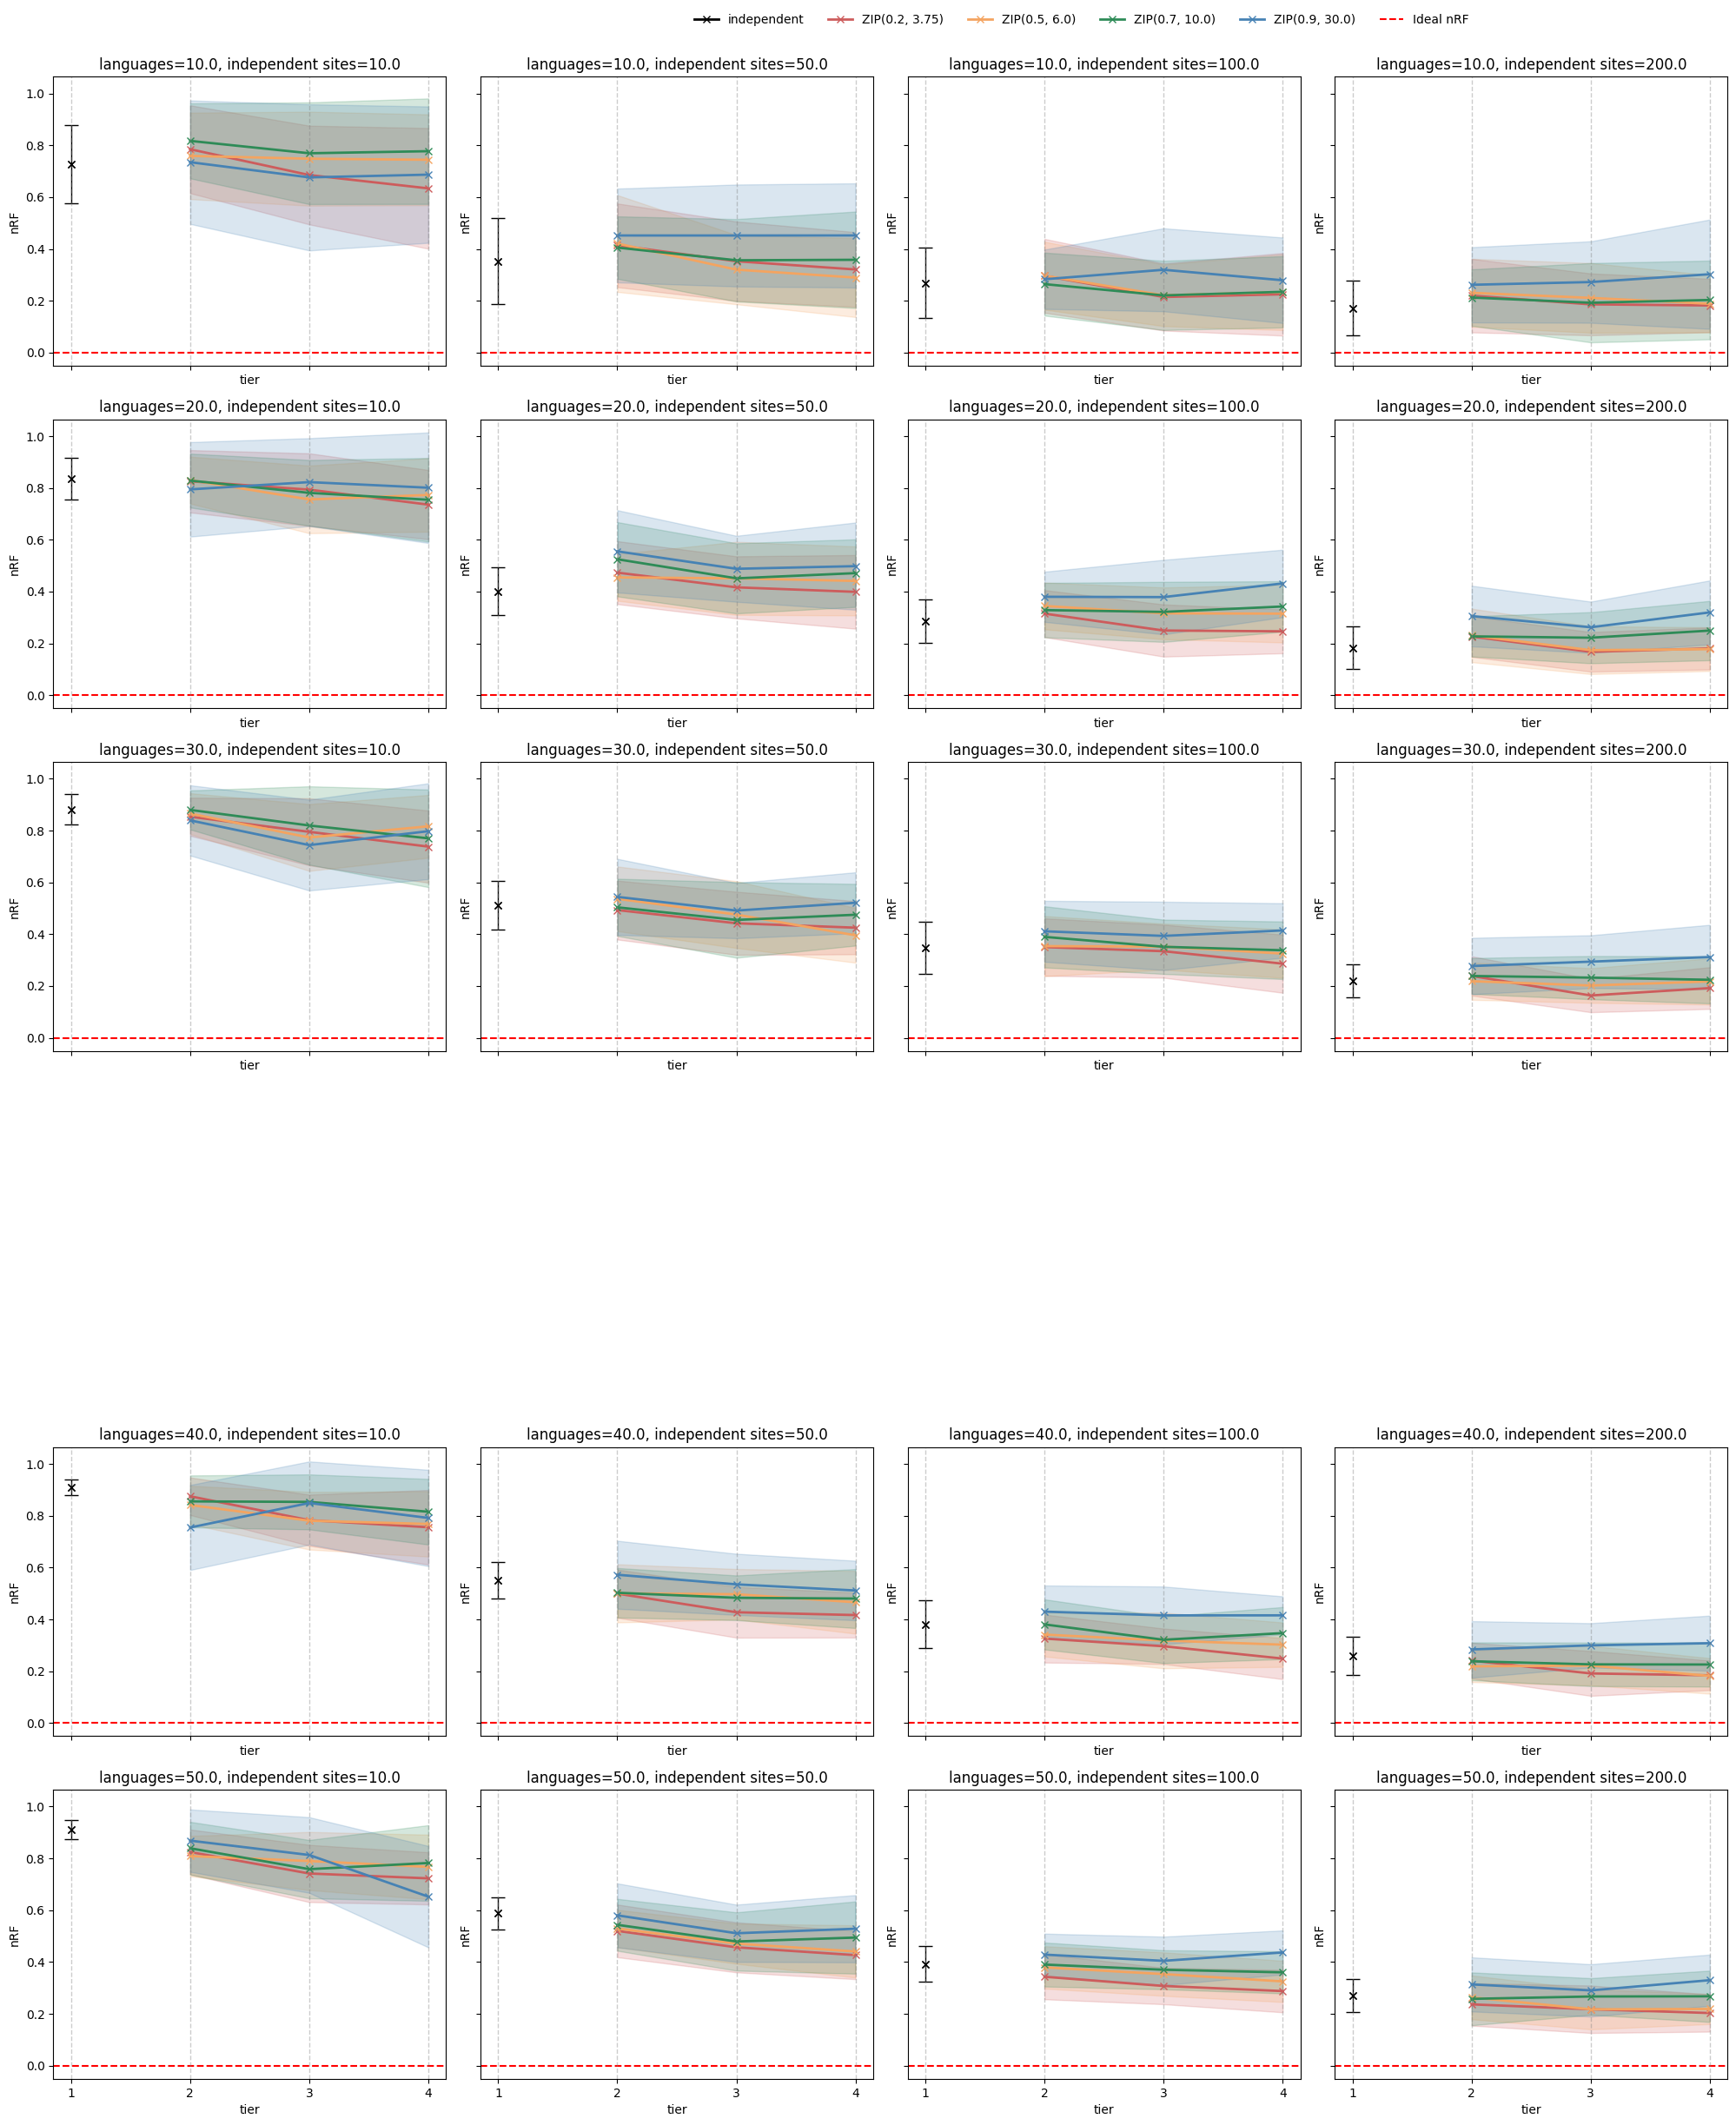

In [20]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["meanNRF"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("nRF")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(0, color="red", linestyle="--", label="Ideal nRF")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

- Clearly more independent data is better from the plot (compare blue dots from left to right)
- But with more independent data adding tiers to the data is less useful (marginal improvement decreases?)
- In most cases, having more dependent data improves the model recovery
- Interestingly, generation needs to be extremely selective or extremely widespread - having ZIP(0.5, 6) actually nullifies the effect of more dependent tiers


make uninteresting plots
- plot amount of data that was created for each step

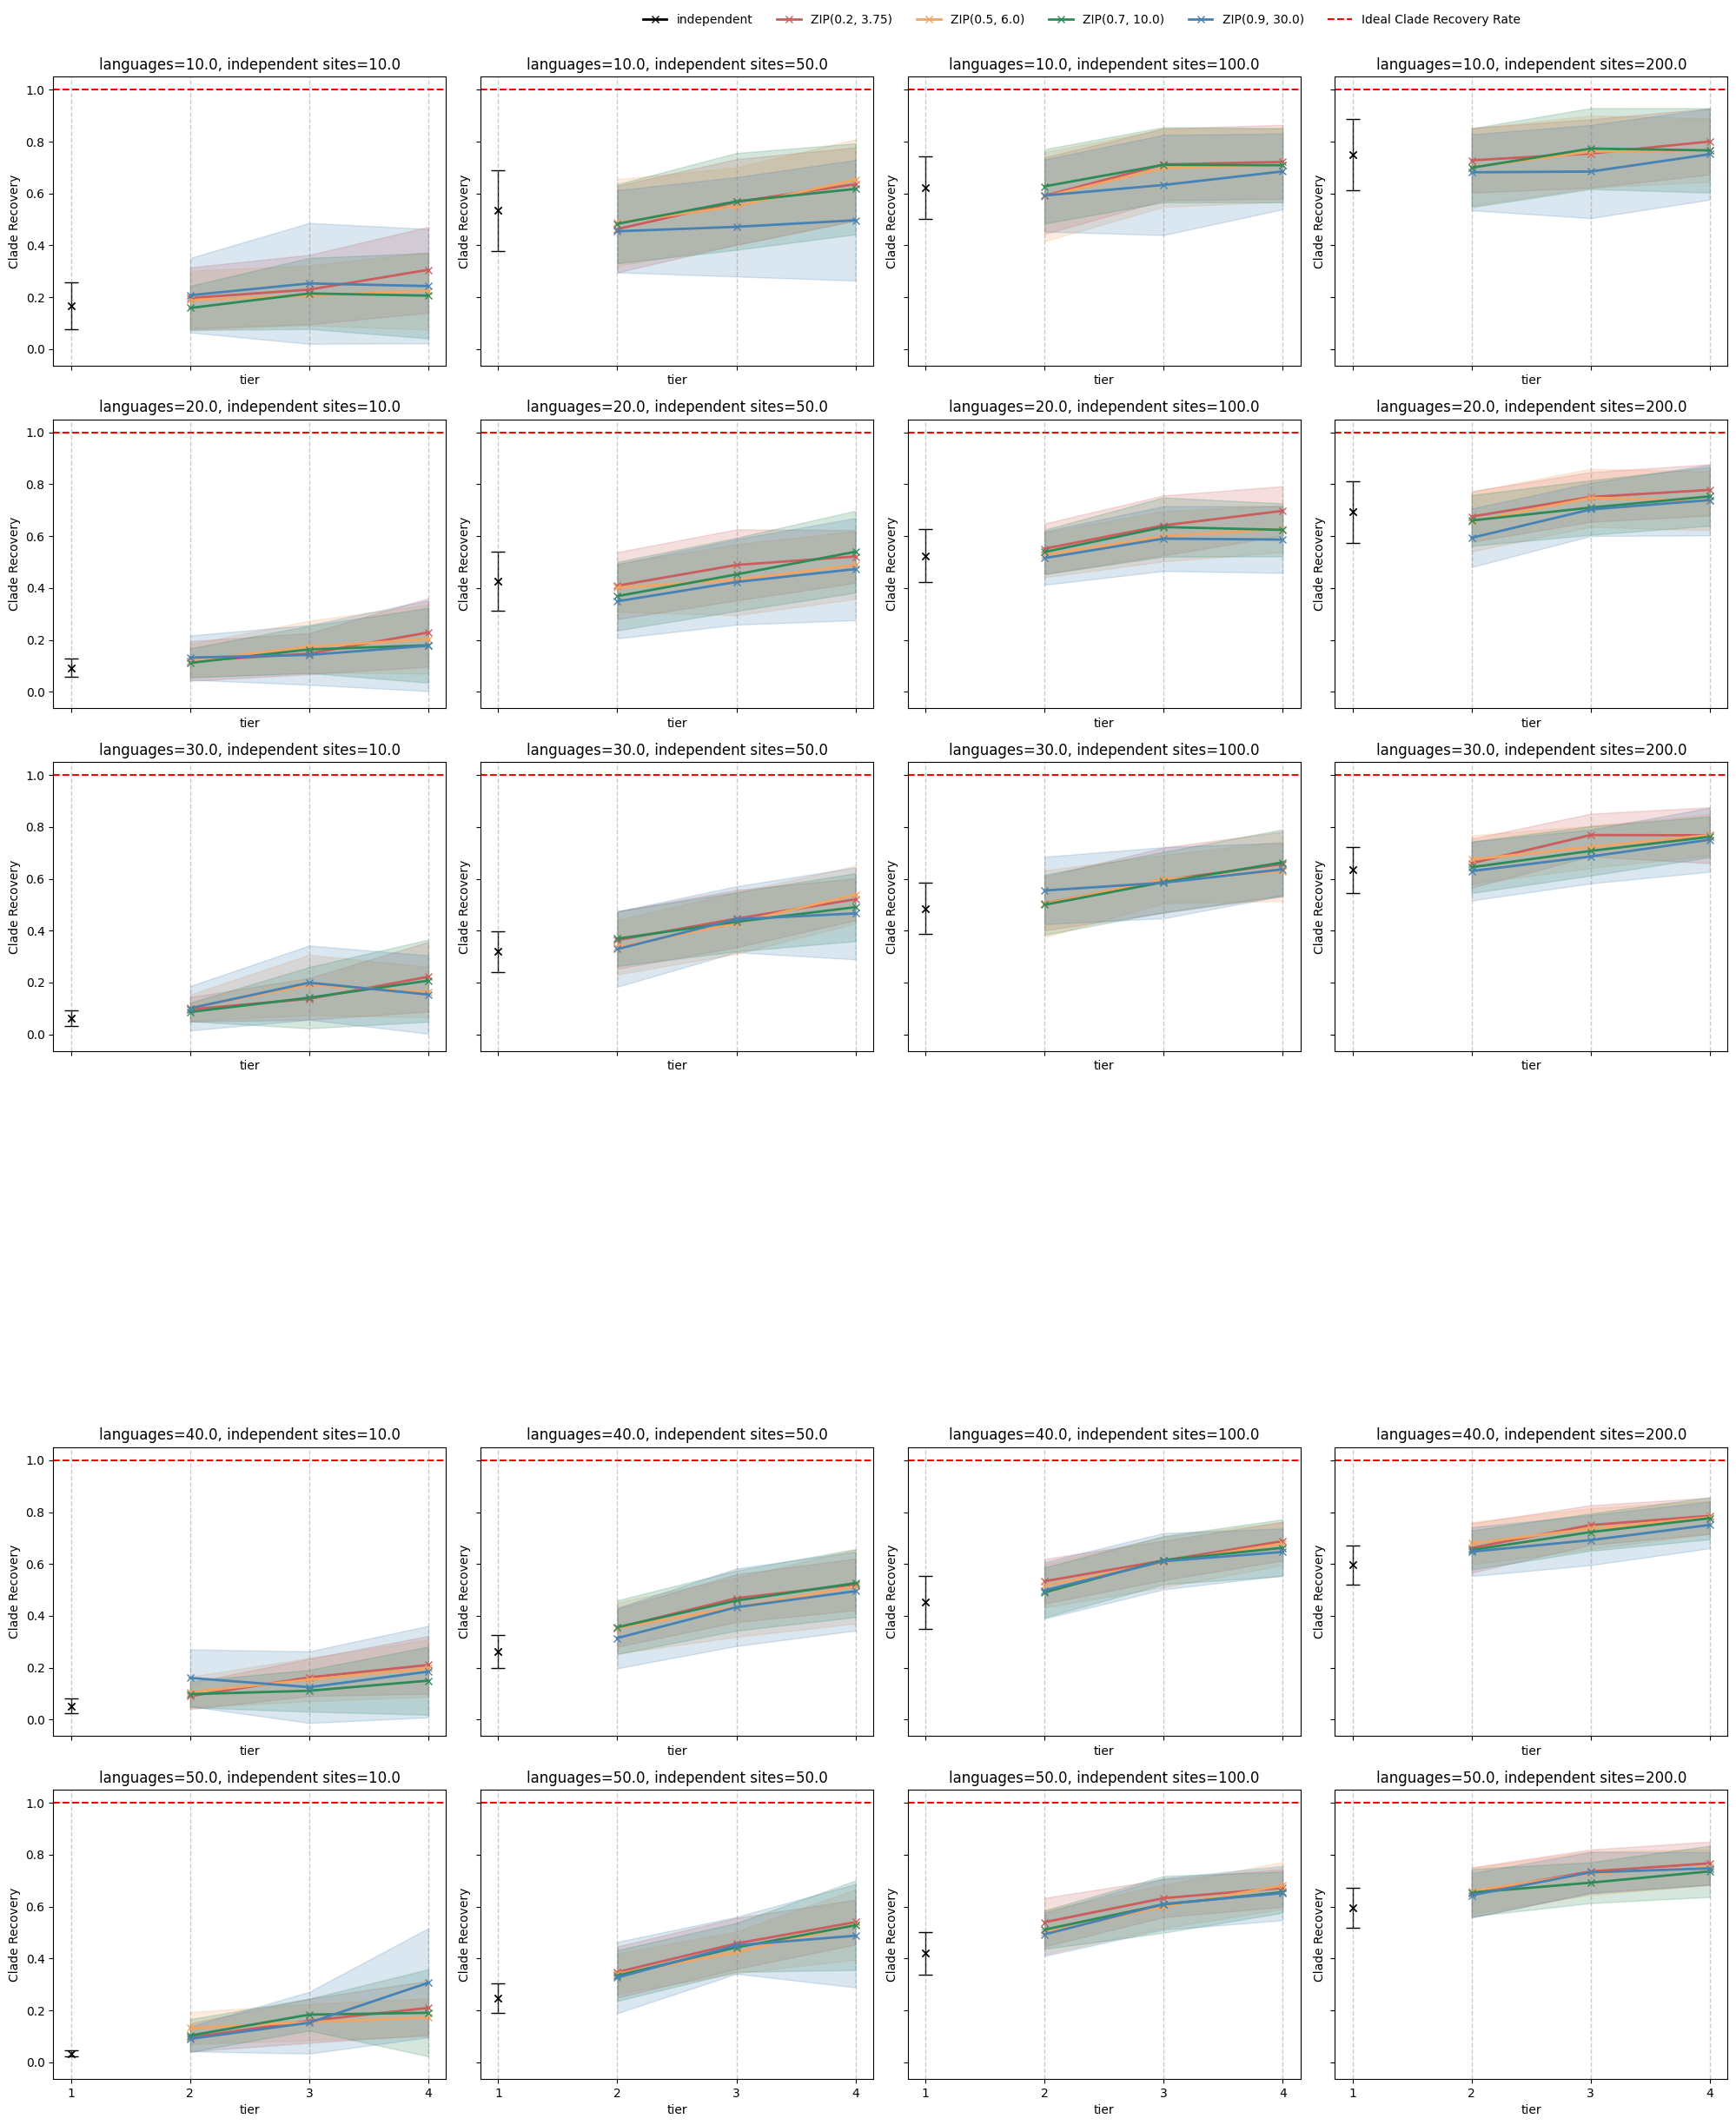

In [21]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["HighSupportCladesProp"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Clade Recovery")
        ax.axhline(1, color="red", linestyle="--", label="Ideal Clade Recovery Rate")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

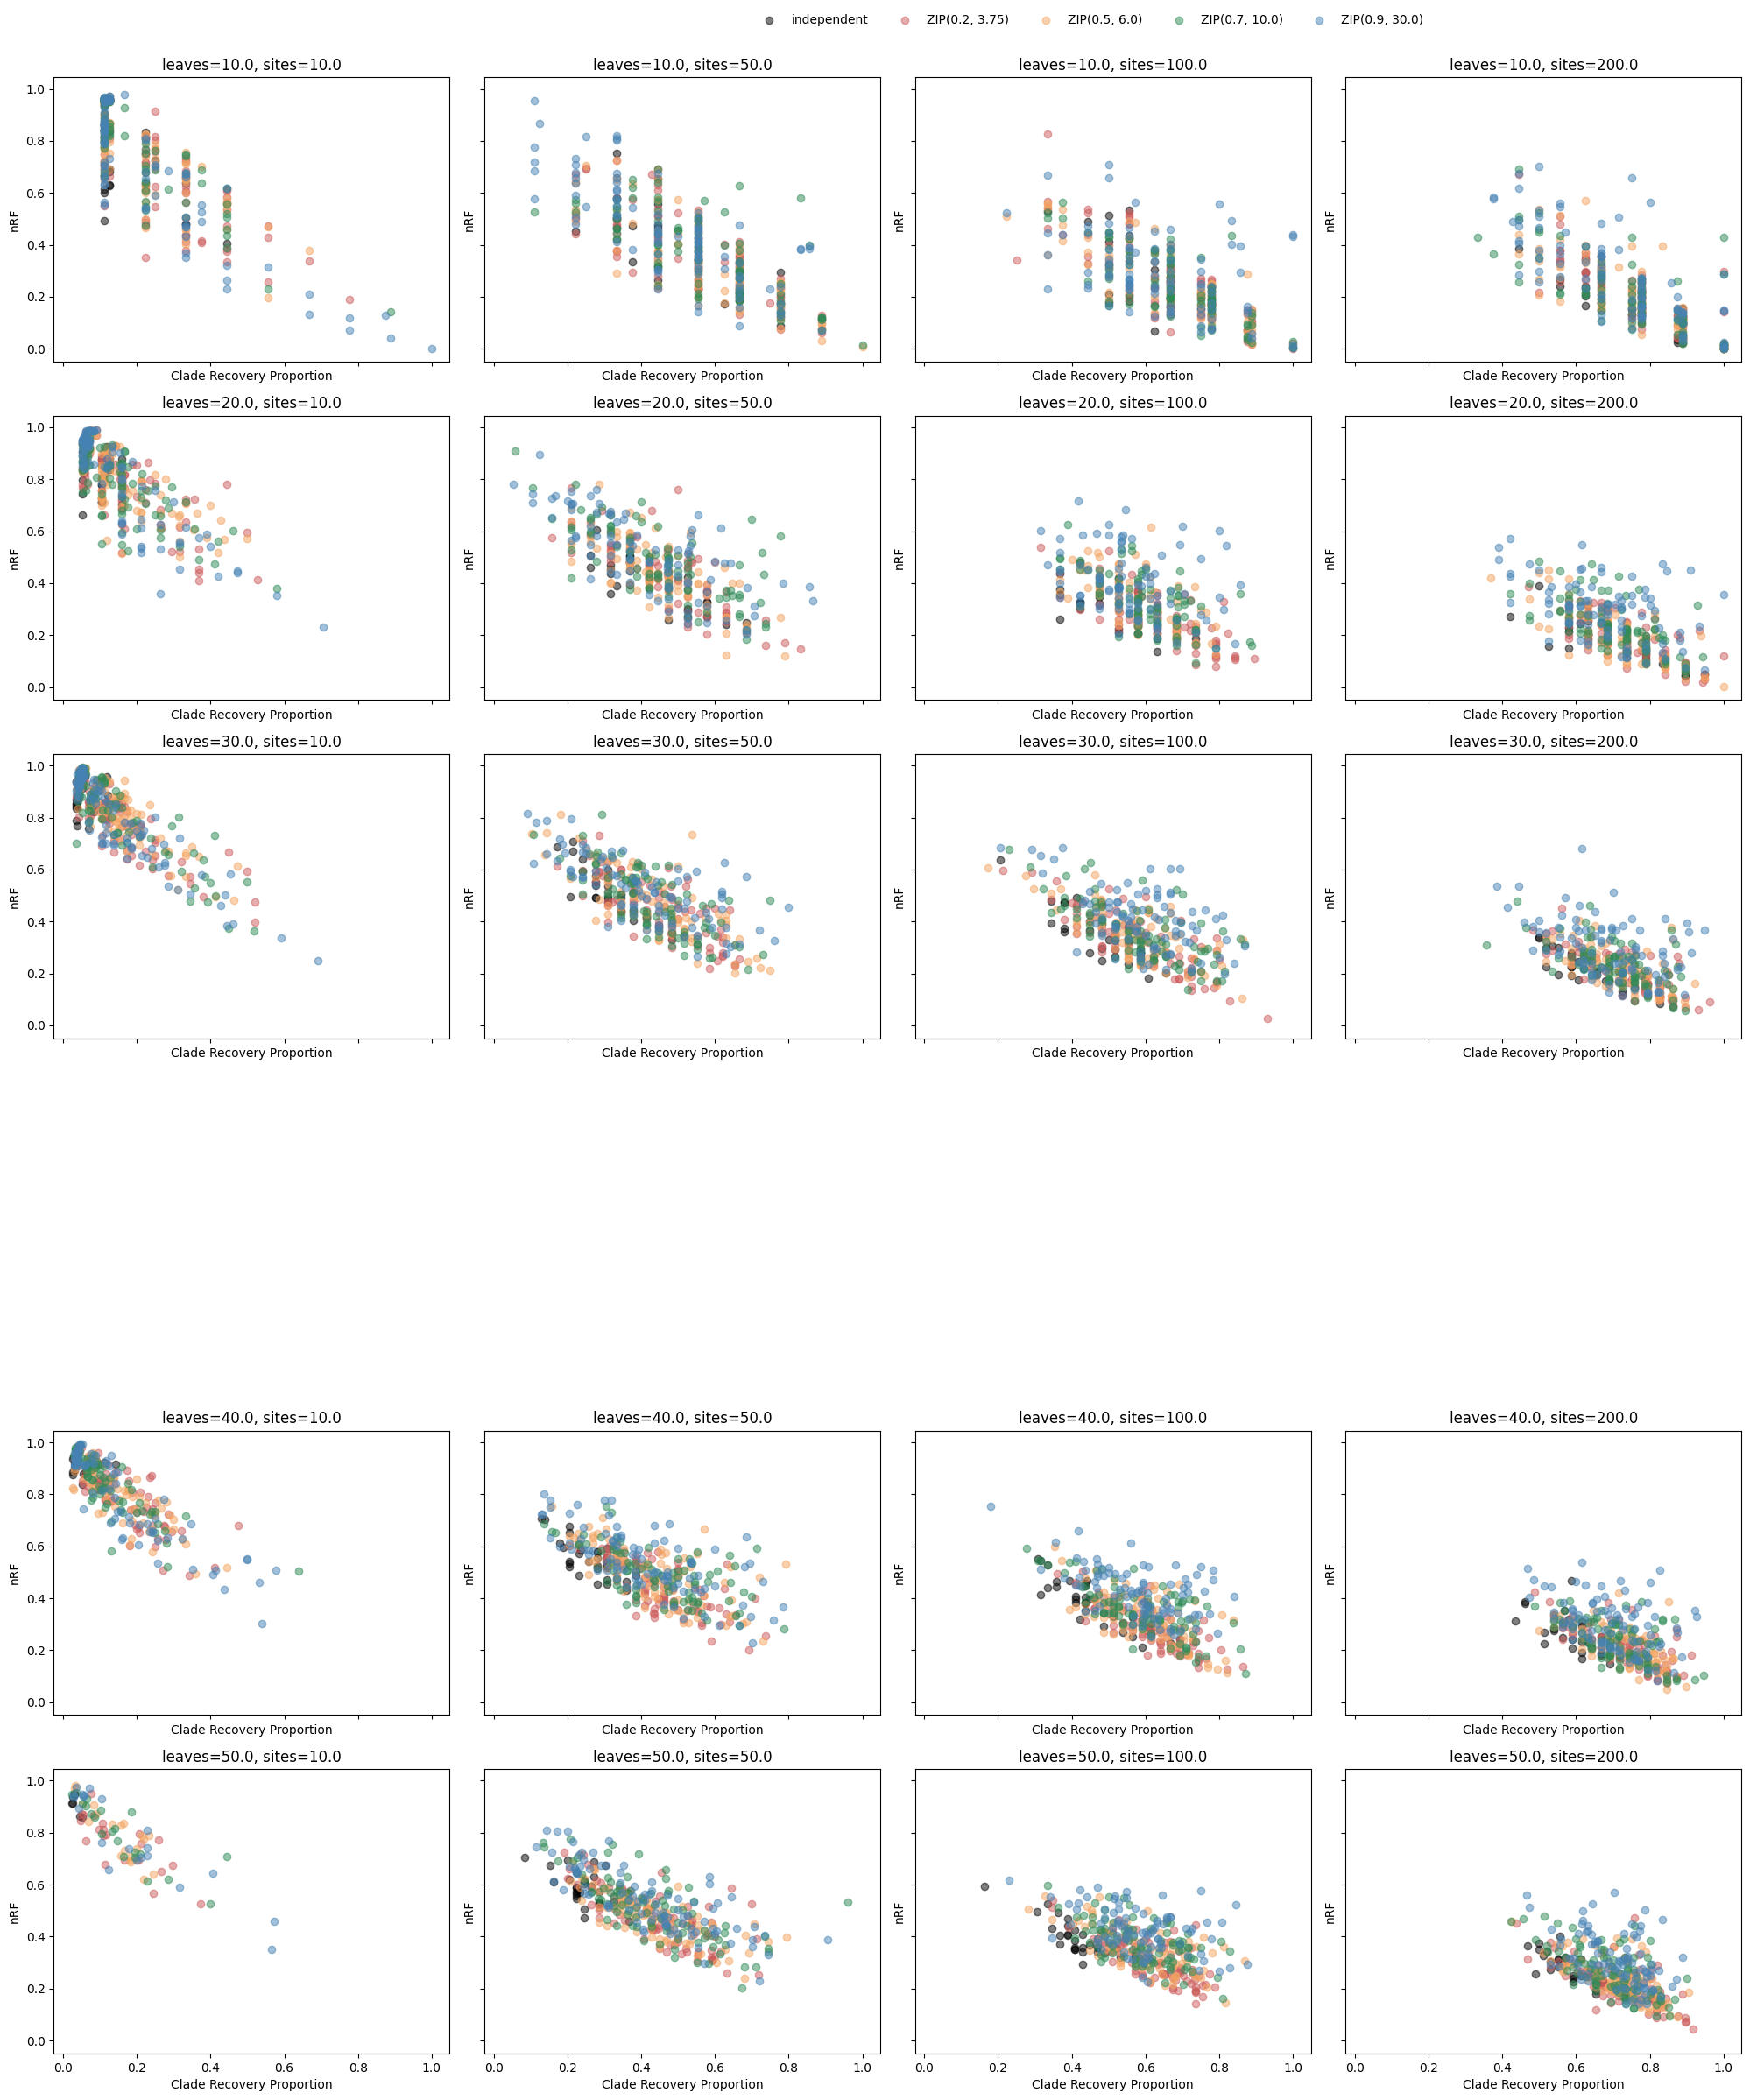

In [22]:
# NOT USED
fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):

        ax = axes[i, j]

        d = df[
            (df["leaves"] == leaves_val) &
            (df["independent_sites"] == sites_val)
        ].copy()

        if d.empty:
            ax.set_visible(False)
            continue

        methods = d["ZIP"].unique()

        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]

            ax.scatter(
                dm["HighSupportCladesProp"],
                dm["meanNRF"],
                alpha=0.5,
                label=m,
                color=colors[k]
            )

        ax.set_title(f"leaves={leaves_val}, sites={sites_val}")
        ax.set_xlabel("Clade Recovery Proportion")
        ax.set_ylabel("nRF")


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

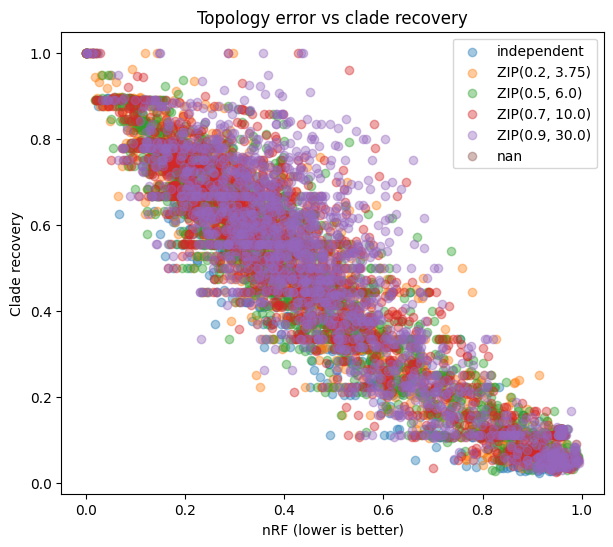

In [23]:
# NOT USED
plt.figure(figsize=(7,6))

for m in df["ZIP"].unique():
    d = df[df["ZIP"] == m]

    plt.scatter(
        d["meanNRF"],
        d["HighSupportCladesProp"],
        alpha=0.4,
        label=m
    )

plt.xlabel("nRF (lower is better)")
plt.ylabel("Clade recovery")
plt.title("Topology error vs clade recovery")
plt.legend()
plt.show()

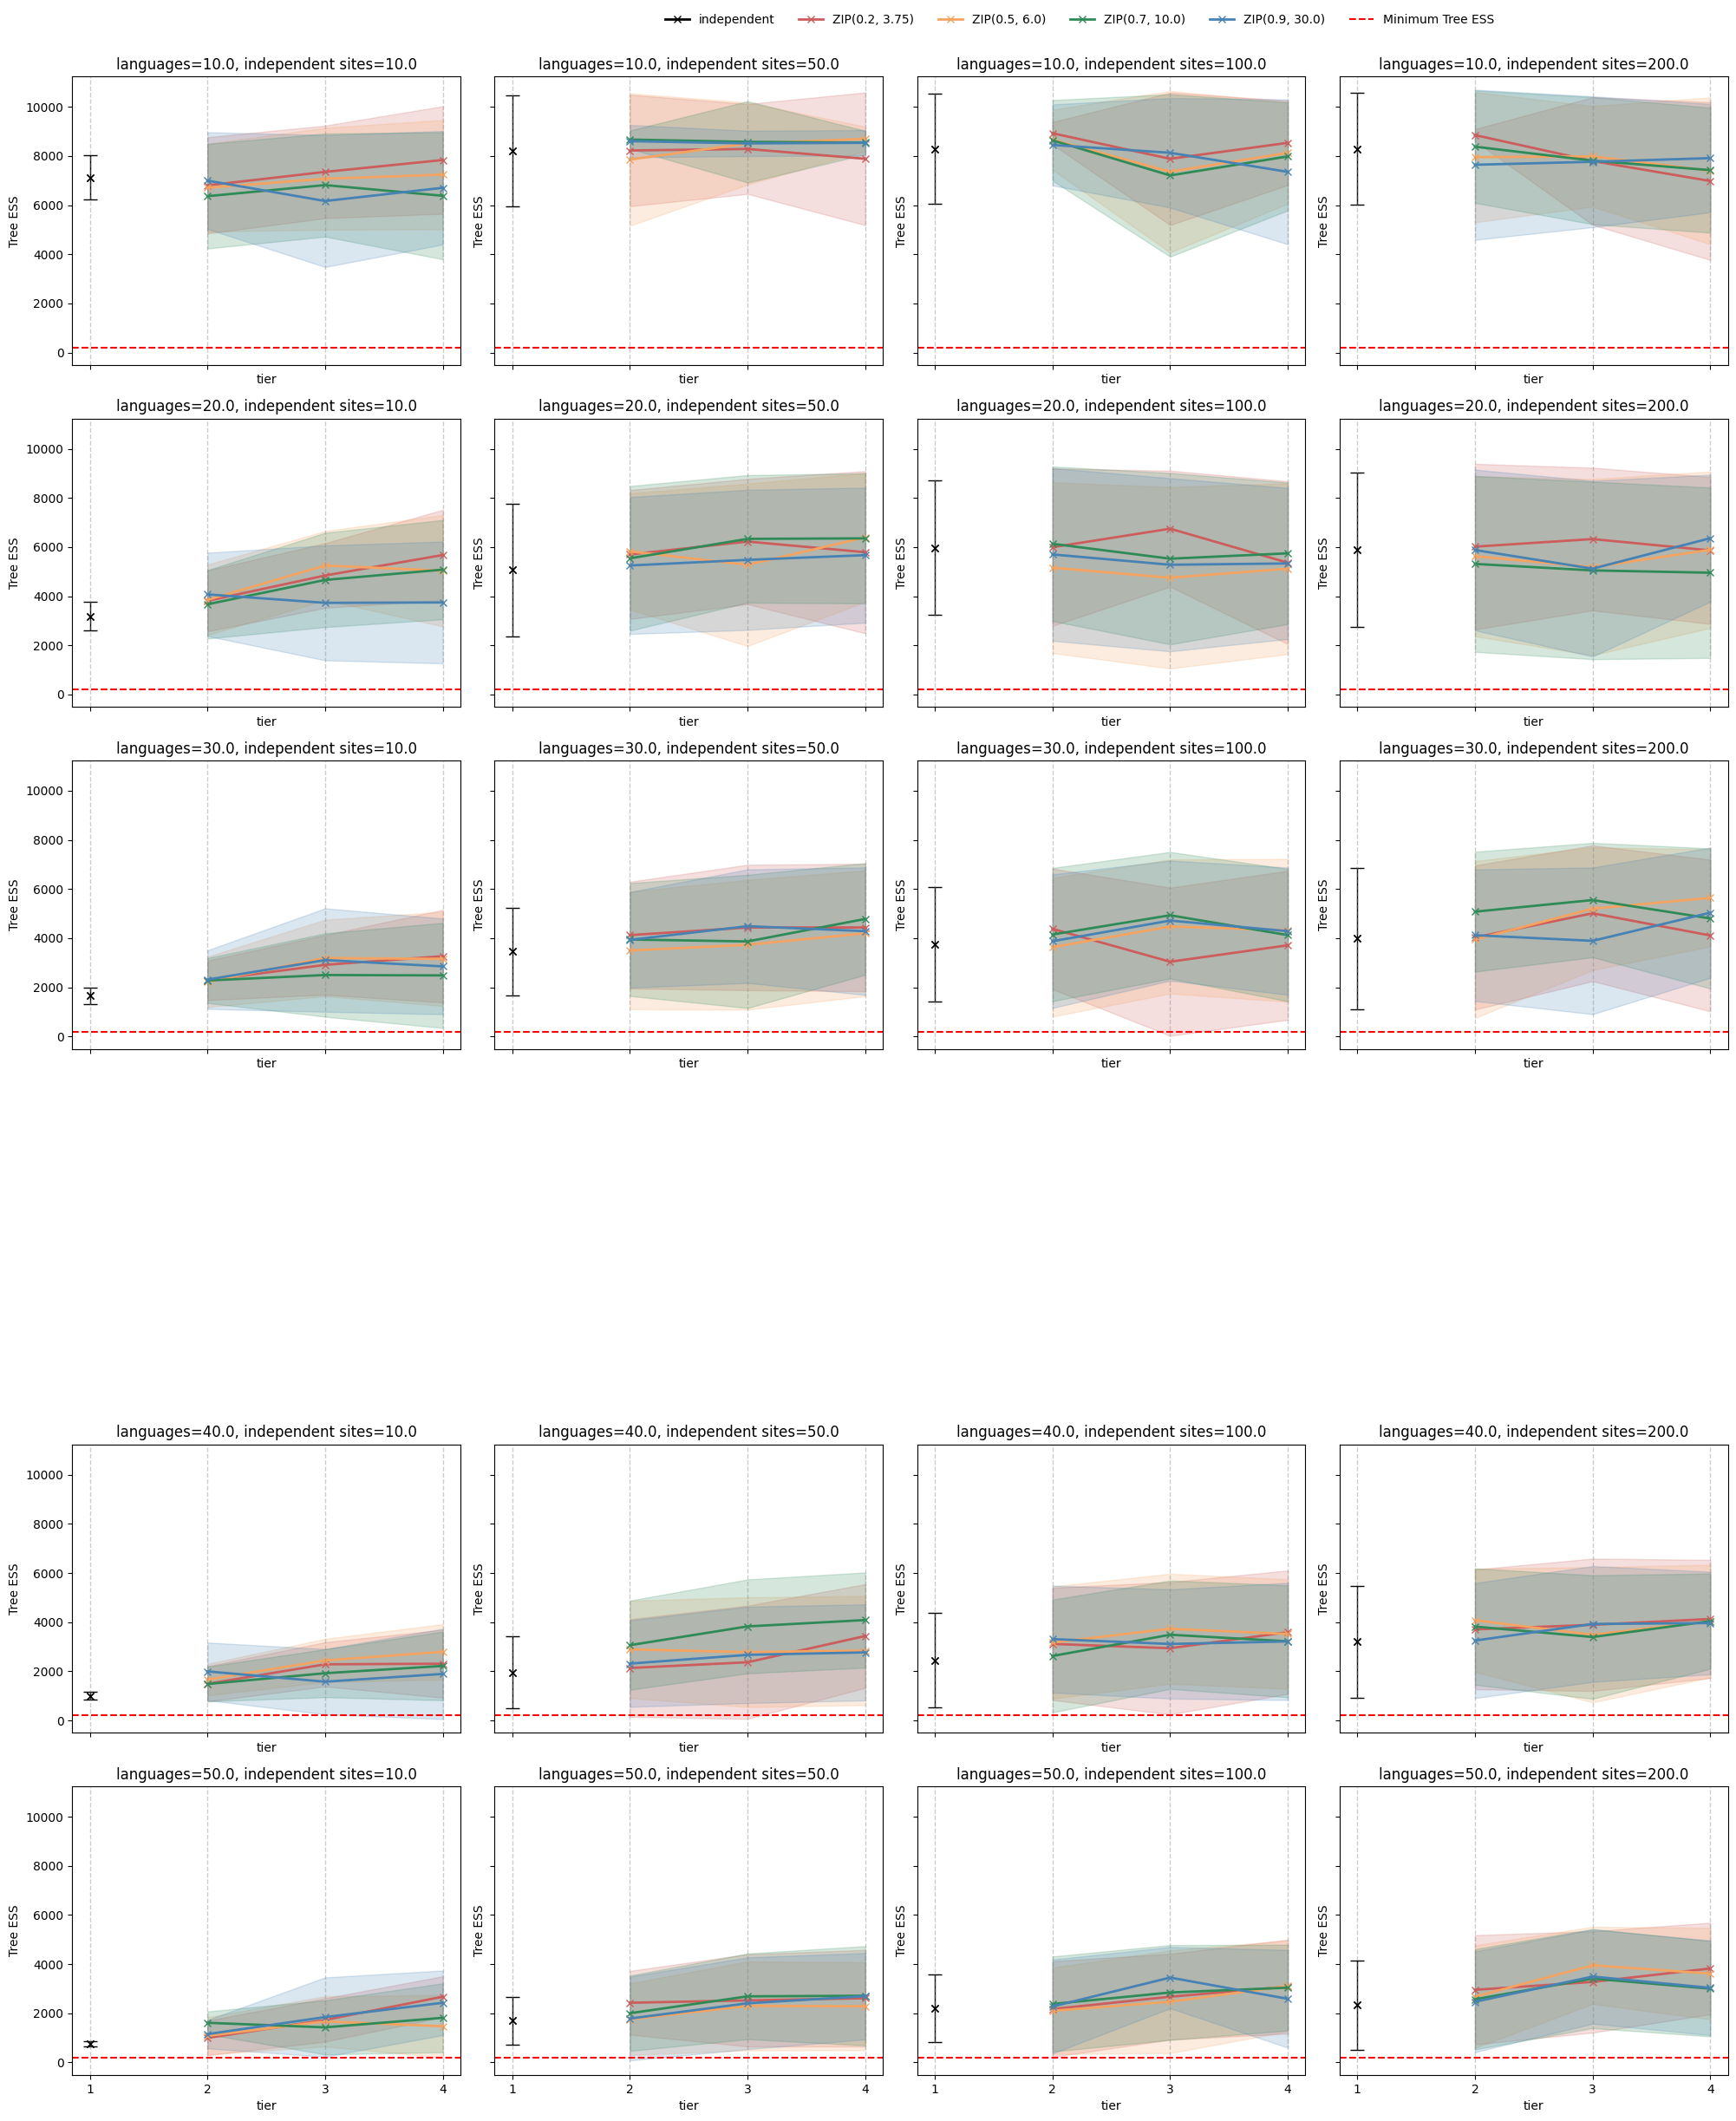

In [24]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["jointESS"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Tree ESS")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(200, color="red", linestyle="--", label="Minimum Tree ESS")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

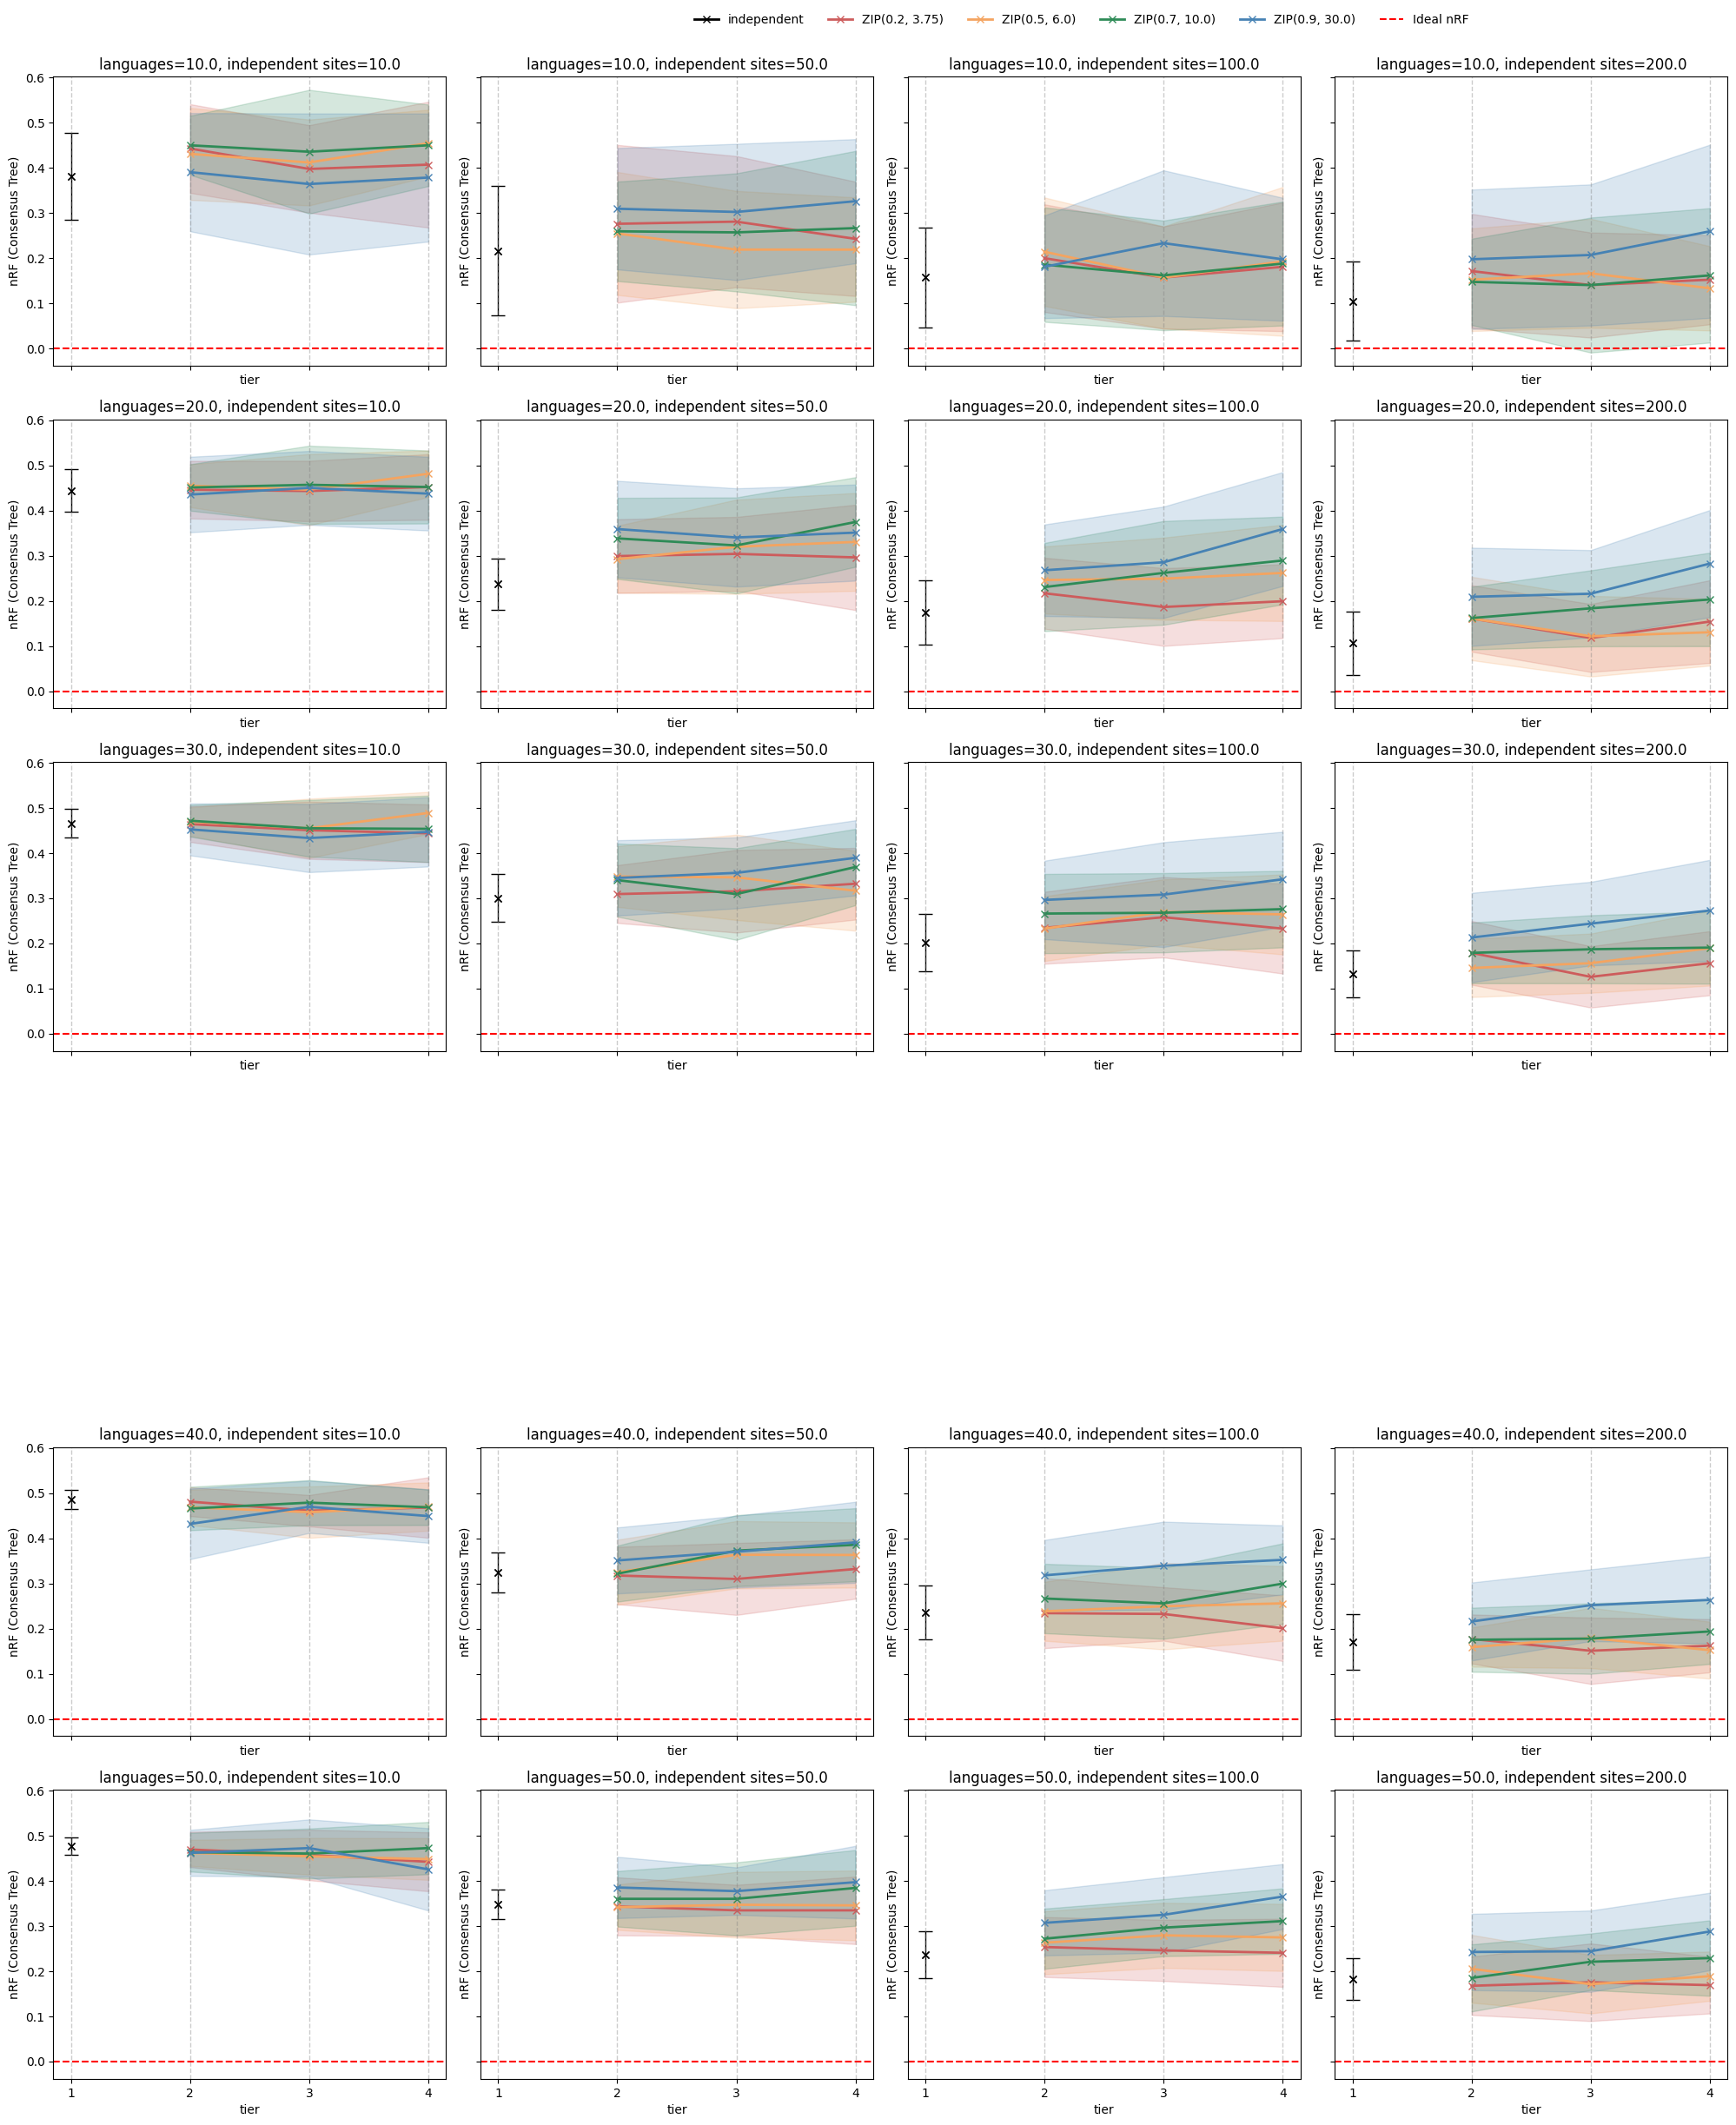

In [25]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["NRFConsensus"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("nRF (Consensus Tree)")
        ax.set_xticks([1, 2, 3, 4])
        ax.axhline(0, color="red", linestyle="--", label="Ideal nRF")
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

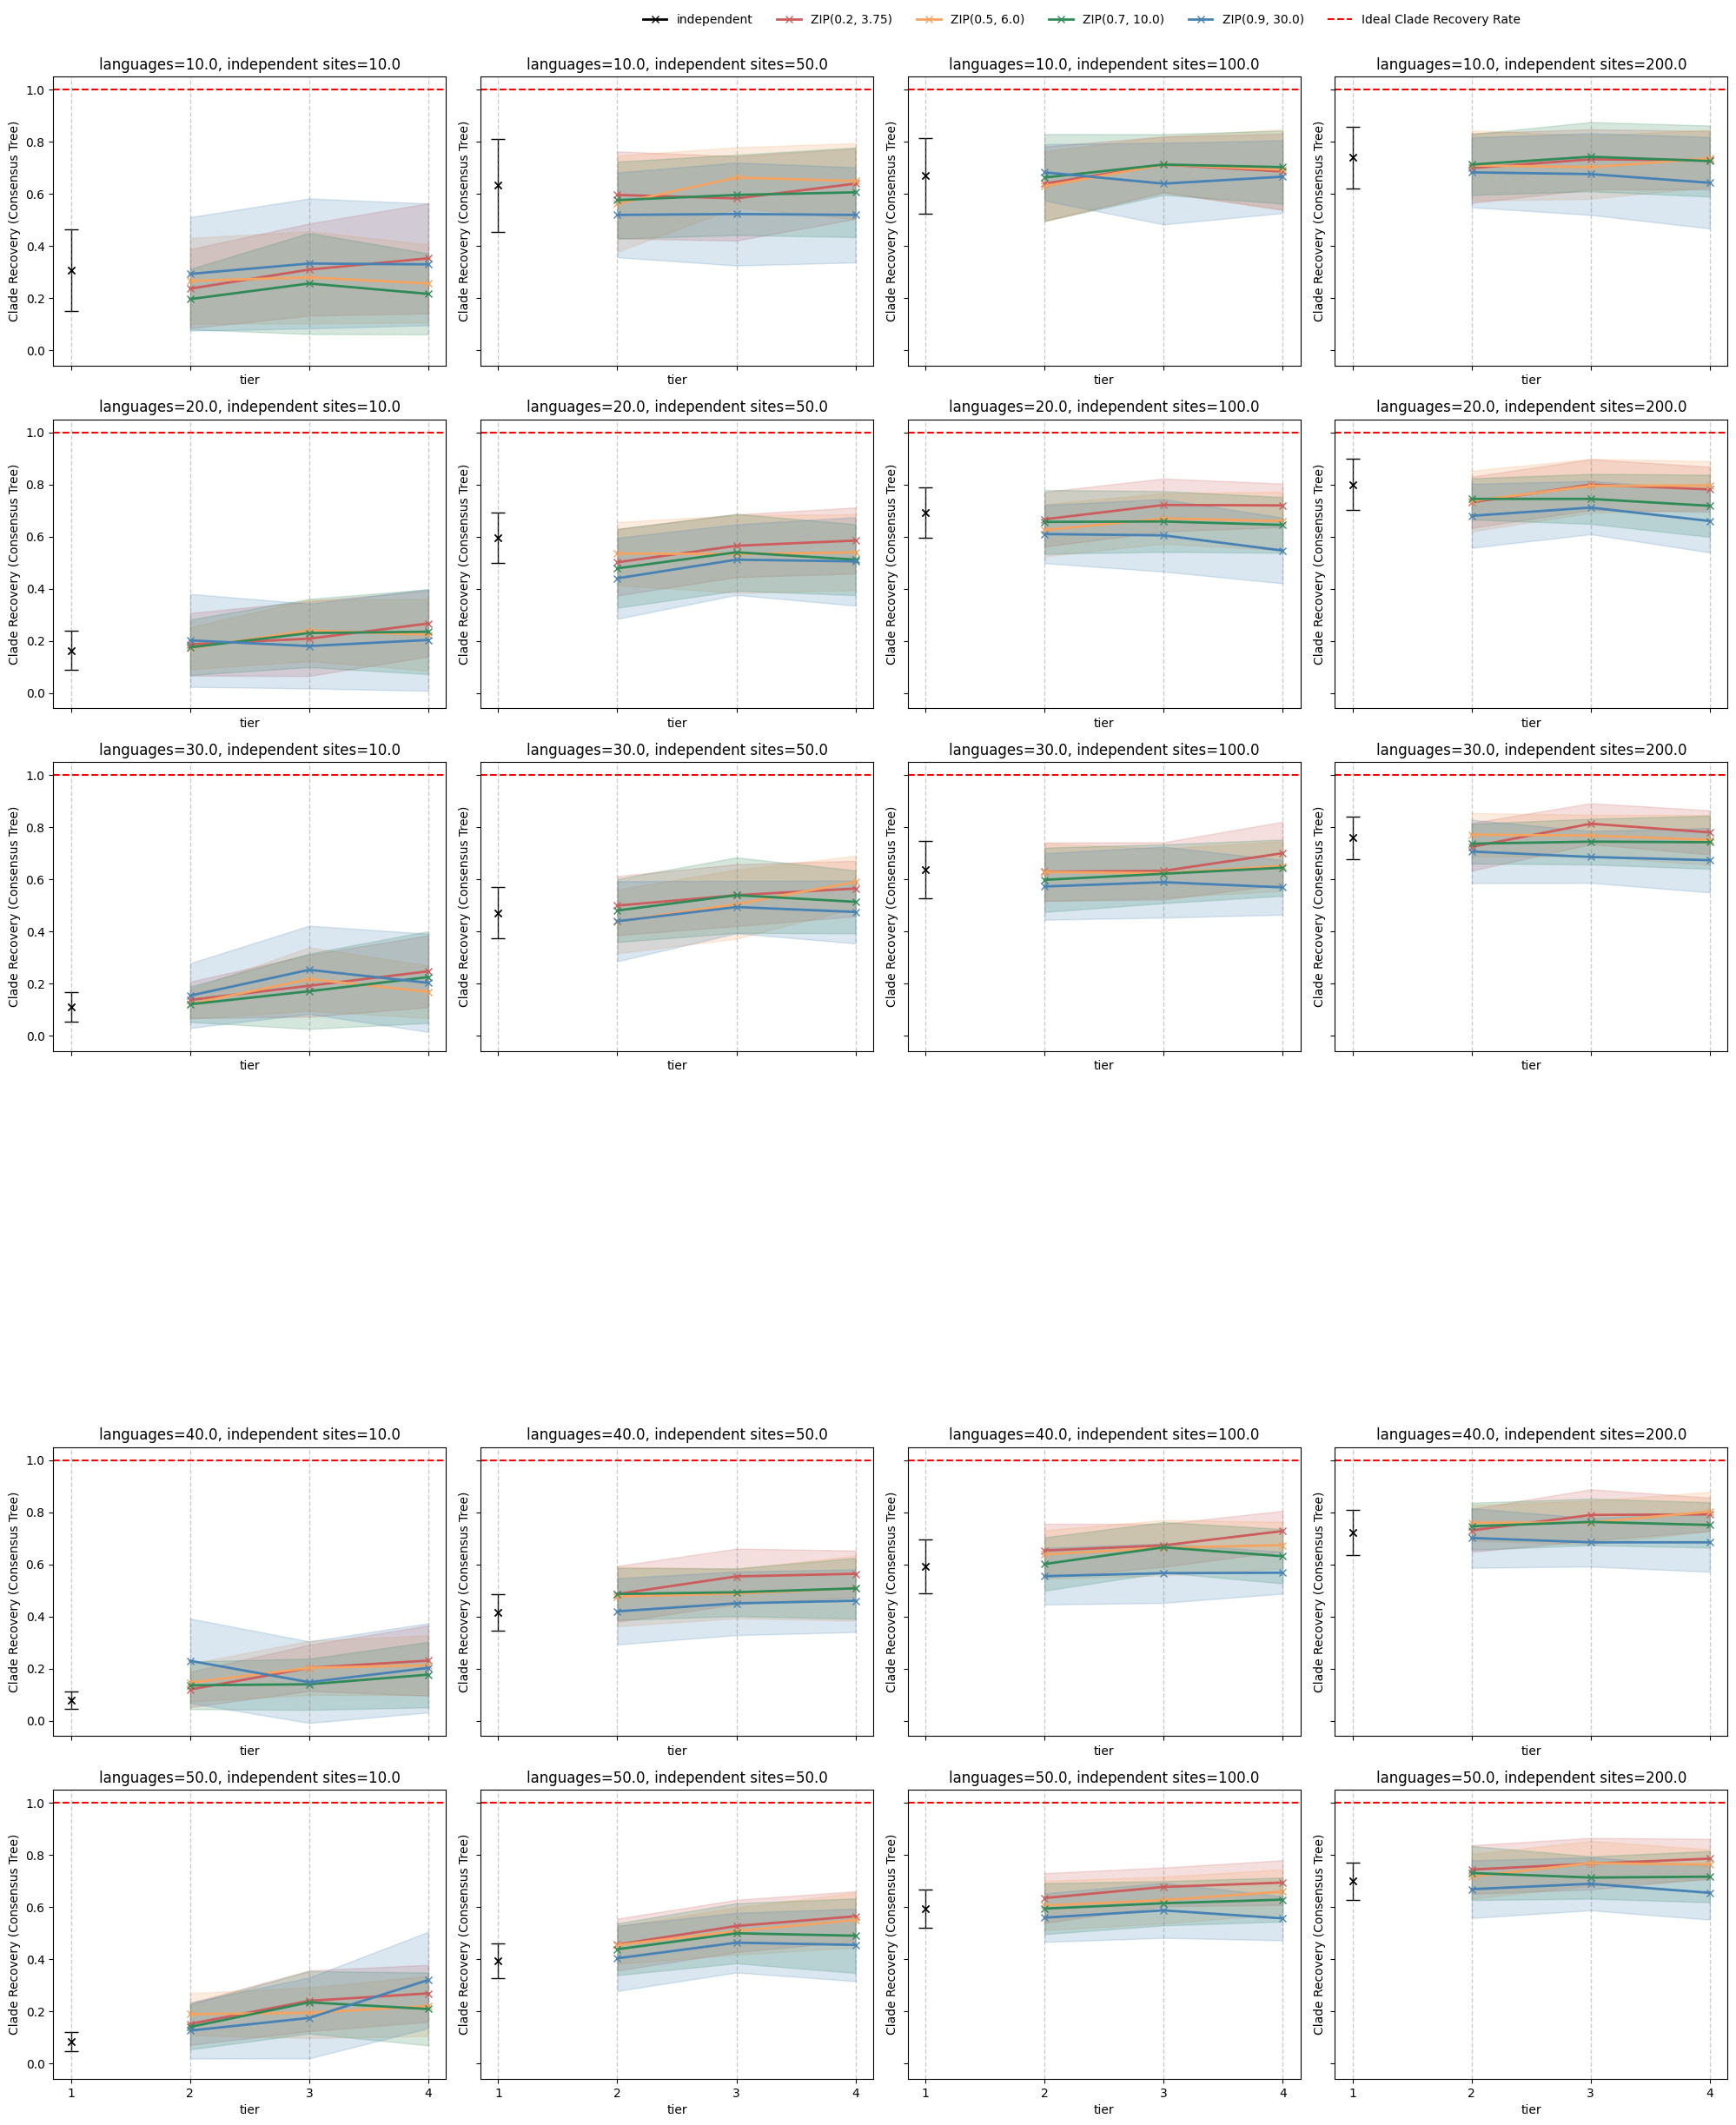

In [26]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["CladeRecoveryConsensus"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Clade Recovery (Consensus Tree)")
        ax.axhline(1, color="red", linestyle="--", label="Ideal Clade Recovery Rate")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()